In [2]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


# **STEP 1 - Load the labelled AR dataset & define features**

In [ ]:
import pandas as pd
import numpy as np

BASE = "/content/drive/MyDrive/AR_Stratified"

# 1) LOAD LABELLED AR DATA
ar = pd.read_csv(f"{BASE}/HMI_AR_2010_2025_ML_READY_16_LABELED_MX3D.csv")

print("AR raw shape:", ar.shape)
print("Columns:", ar.columns.tolist())

# Ensure correct types
ar["T_REC_dt"] = pd.to_datetime(ar["T_REC_dt"], errors="coerce")
ar["NOAA_AR"] = pd.to_numeric(ar["NOAA_AR"], errors="coerce").astype("Int64")
ar["year"] = pd.to_numeric(ar["year"], errors="coerce").astype("Int64")

# Drop rows with missing key fields
ar = ar.dropna(subset=["T_REC_dt", "NOAA_AR", "label_MX_3d"]).copy()
ar["label_MX_3d"] = ar["label_MX_3d"].astype(int)

print("AR after cleaning:", ar.shape)

# 16 magnetic features we will feed LSTM
feature_cols = [
    "MEANGBZ", "MEANGAM", "MEANGBT", "MEANGBH",
    "MEANJZD", "TOTUSJZ", "MEANALP", "MEANJZH",
    "ABSNJZH", "SAVNCPP", "MEANSHR", "SHRGT45",
    "R_VALUE", "USFLUX", "TOTPOT", "TOTUSJH"
]

# Keep only rows where we have all features
ar = ar.dropna(subset=feature_cols).copy()
print("AR after dropping rows with NaN features:", ar.shape)

# Sort for sanity
ar = ar.sort_values(["NOAA_AR", "T_REC_dt"]).reset_index(drop=True)


AR raw shape: (22355, 21)
Columns: ['T_REC_dt', 'year', 'NOAA_AR', 'MEANGBZ', 'MEANGAM', 'MEANGBT', 'MEANGBH', 'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANJZH', 'ABSNJZH', 'SAVNCPP', 'MEANSHR', 'SHRGT45', 'R_VALUE', 'USFLUX', 'TOTPOT', 'TOTUSJH', 'label_MX_3d', 'future_max_class']
AR after cleaning: (22355, 21)
AR after dropping rows with NaN features: (22130, 21)


# **STEP 2 – Resample each AR to a clean 6-hour grid**

Here we:

  Group by NOAA_AR

  Resample its time series to 6-hour bins

  For features: forward-fill (use last known value)

  For labels: within each 6h bin, if any snapshot had label 1 → bin label = 1




In [ ]:
# RESAMPLE TO 6-HOUR GRID PER AR

def resample_ar_group(g):
    g = g.set_index("T_REC_dt").sort_index()

    # Resample features: 6H, forward-fill values
    g_res = g[feature_cols + ["label_MX_3d"]].resample("6H").ffill()

    # Label: if any positive in 6h bin, bin = 1
    g_res["label_MX_3d"] = g["label_MX_3d"].resample("6H").max().fillna(0).astype(int)

    # Restore NOAA_AR and year
    g_res["NOAA_AR"] = g["NOAA_AR"].iloc[0]
    g_res["year"] = g_res.index.year

    return g_res.reset_index().rename(columns={"T_REC_dt": "T_REC_dt"})

print("Resampling to 6H grid... (this may take a few seconds)")
ar_6h_list = []
for ar_num, g in ar.groupby("NOAA_AR"):
    ar_6h_list.append(resample_ar_group(g))

ar_6h = pd.concat(ar_6h_list, ignore_index=True)

print("AR 6H shape:", ar_6h.shape)
print(ar_6h.head())


Resampling to 6H grid... (this may take a few seconds)


Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-3653058838.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  g_res = g[feature_cols + ["label_MX_3d"]].resample("6H").ffill()
/tmp/ipython-input-3653058838.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  g_res["label_MX_3d"] = g["label_MX_3d"].resample("6H").max().fillna(0).astype(int)
/tmp/ipython-input-3653058838.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  g_res = g[feature_cols + ["label_MX_3d"]].resample("6H").ffill()
/tmp/ipython-input-3653058838.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  g_res["label_MX_3d"] = g["label_MX_3d"].resample("6H").max().fillna(0).astype(int)
/tmp/ipython-input-3653058838.py:7: FutureWarning: 'H' is deprecated and will be removed in a future versio

AR 6H shape: (105252, 20)
             T_REC_dt  MEANGBZ  MEANGAM  MEANGBT  MEANGBH   MEANJZD  \
0 2010-05-03 12:00:00  163.413   33.823  157.335   82.652  0.853483   
1 2010-05-03 18:00:00  163.413   33.823  157.335   82.652  0.853483   
2 2010-05-04 00:00:00  163.413   33.823  157.335   82.652  0.853483   
3 2010-05-04 06:00:00  163.413   33.823  157.335   82.652  0.853483   
4 2010-05-04 12:00:00  114.931   23.572  111.969   48.270 -0.446712   

        TOTUSJZ   MEANALP   MEANJZH  ABSNJZH       SAVNCPP  MEANSHR  SHRGT45  \
0  1.032882e+12  0.022914  0.018148   19.782  6.899534e+11   24.717    4.954   
1  1.032882e+12  0.022914  0.018148   19.782  6.899534e+11   24.717    4.954   
2  1.032882e+12  0.022914  0.018148   19.782  6.899534e+11   24.717    4.954   
3  1.032882e+12  0.022914  0.018148   19.782  6.899534e+11   24.717    4.954   
4  1.144288e+12 -0.006346 -0.003990    7.947  4.758987e+11   17.322    0.000   

   R_VALUE        USFLUX        TOTPOT  TOTUSJH  label_MX_3d  NOAA

/tmp/ipython-input-3653058838.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  g_res = g[feature_cols + ["label_MX_3d"]].resample("6H").ffill()
/tmp/ipython-input-3653058838.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  g_res["label_MX_3d"] = g["label_MX_3d"].resample("6H").max().fillna(0).astype(int)
/tmp/ipython-input-3653058838.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  g_res = g[feature_cols + ["label_MX_3d"]].resample("6H").ffill()
/tmp/ipython-input-3653058838.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  g_res["label_MX_3d"] = g["label_MX_3d"].resample("6H").max().fillna(0).astype(int)
/tmp/ipython-input-3653058838.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  g_res = g[feature_cols

# **STEP 3 – Build 3-day (12-step) sequences per AR**

Now we:

Use sequence length = 12 time steps (3 days × 6h)

For each AR:

Slide over its 6h time series

Take blocks of 12 rows → this becomes one sequence

Label for the sequence = label_MX_3d at the last step in the block

In [ ]:
SEQ_LEN = 12  # 3 days * 4 steps/day (6-hour steps)

X_list = []
y_list = []
meta = []  # to keep some info about each sequence (AR, end time, year)

for ar_num, g in ar_6h.groupby("NOAA_AR"):
    g = g.sort_values("T_REC_dt")
    feats = g[feature_cols].values
    labels = g["label_MX_3d"].values
    times = g["T_REC_dt"].values
    years = g["year"].values

    if len(g) < SEQ_LEN:
        continue  # not enough points to form even 1 sequence

    for i in range(len(g) - SEQ_LEN + 1):
        seq_feats = feats[i:i+SEQ_LEN]          # shape (12, 16)
        seq_label = labels[i+SEQ_LEN-1]         # label at last time-step
        end_time = times[i+SEQ_LEN-1]
        end_year = years[i+SEQ_LEN-1]

        X_list.append(seq_feats)
        y_list.append(seq_label)
        meta.append({
            "NOAA_AR": ar_num,
            "end_time": end_time,
            "end_year": int(end_year),
            "label_MX_3d": int(seq_label)
        })

X_seq = np.array(X_list)   # shape: (N_sequences, 12, 16)
y_seq = np.array(y_list)   # shape: (N_sequences,)

meta_df = pd.DataFrame(meta)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print("Meta sample:")
print(meta_df.head())

print("\nLabel distribution in sequences:")
unique, counts = np.unique(y_seq, return_counts=True)
print(dict(zip(unique, counts)))


X_seq shape: (81076, 12, 16)
y_seq shape: (81076,)
Meta sample:
   NOAA_AR            end_time  end_year  label_MX_3d
0    11064 2010-05-04 06:00:00      2010            0
1    11064 2010-05-04 12:00:00      2010            0
2    11064 2010-05-04 18:00:00      2010            0
3    11064 2010-05-05 00:00:00      2010            0
4    11064 2010-05-05 06:00:00      2010            0

Label distribution in sequences:
{np.int64(0): np.int64(80042), np.int64(1): np.int64(1034)}




---



# **BASELINE PIPELINE MODEL **

# **1. FEATURE EXTRACTION (12×16 → 64 features)**

**BASELINE FEATURE EXTRACTOR (Mean, Std, Max, Last — 64 features)**

In [ ]:
import numpy as np
import pandas as pd

def extract_baseline_features(X_seq):
    """
    Convert each dynamic sequence (T=12 timesteps, F=16 features)
    into a static 64-feature vector for classical ML models.
    """
    features = []

    for seq in X_seq:
        seq = np.array(seq)

        mean_vals = seq.mean(axis=0)       # 16
        std_vals  = seq.std(axis=0)        # 16
        max_vals  = seq.max(axis=0)        # 16
        last_vals = seq[-1]                # 16

        combined = np.concatenate([mean_vals, std_vals, max_vals, last_vals])
        features.append(combined)

    return np.array(features)


3. **APPLY FEATURE EXTRACTION TO SPLITS (same split as LSTM)**

In [ ]:
X_train_b = extract_baseline_features(X_train)
X_val_b   = extract_baseline_features(X_val)
X_test_b  = extract_baseline_features(X_test)

print("Baseline shapes:")
print(X_train_b.shape, X_val_b.shape, X_test_b.shape)


Baseline shapes:
(44723, 64) (7839, 64) (28514, 64)


**4. LOGISTIC REGRESSION BASELINE (Publish-Ready)**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

log_clf = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    solver="liblinear"
)

log_clf.fit(X_train_b, y_train)

y_pred_log = log_clf.predict(X_test_b)
y_prob_log = log_clf.predict_proba(X_test_b)[:,1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_log, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))


=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0     0.9977    0.2845    0.4428     27884
           1     0.0298    0.9714    0.0578       630

    accuracy                         0.2997     28514
   macro avg     0.5137    0.6280    0.2503     28514
weighted avg     0.9763    0.2997    0.4342     28514

ROC-AUC: 0.8290612697046494


**5. RANDOM FOREST BASELINE (Strong Benchmark)**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_b, y_train)

y_pred_rf = rf_clf.predict(X_test_b)
y_prob_rf = rf_clf.predict_proba(X_test_b)[:,1]

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


=== Random Forest Results ===
              precision    recall  f1-score   support

           0     0.9779    1.0000    0.9888     27884
           1     0.0000    0.0000    0.0000       630

    accuracy                         0.9779     28514
   macro avg     0.4890    0.5000    0.4944     28514
weighted avg     0.9563    0.9779    0.9670     28514

ROC-AUC: 0.8128408964121201


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


6. **SOLAR METRICS (TSS + HSS)**

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

def tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    TPR = tp / (tp + fn + 1e-9)
    FPR = fp / (fp + tn + 1e-9)
    TSS = TPR - FPR

    HSS = (2 * (tp*tn - fp*fn)) / (
        (tp+fn)*(fn+tn) + (tp+fp)*(fp+tn) + 1e-9
    )

    return TSS, HSS

# Logistic Regression
tss_log, hss_log = tss_hss(y_test, y_pred_log)
print("Logistic Regression → TSS:", tss_log, "HSS:", hss_log)

# Random Forest
tss_rf, hss_rf = tss_hss(y_test, y_pred_rf)
print("Random Forest → TSS:", tss_rf, "HSS:", hss_rf)


Logistic Regression → TSS: 0.2559286431527761 HSS: 0.015546240183459464
Random Forest → TSS: 0.0 HSS: 0.0




---



# **STEP 4 – Save the sequence data for reuse**

Let’s save them as .npy and metadata as .csv:

In [ ]:
np.save(f"{BASE}/X_seq_6h_3d_MX.npy", X_seq)
np.save(f"{BASE}/y_seq_6h_3d_MX.npy", y_seq)
meta_df.to_csv(f"{BASE}/SEQ_META_6h_3d_MX.csv", index=False)

print("Saved:")
print(f"  {BASE}/X_seq_6h_3d_MX.npy")
print(f"  {BASE}/y_seq_6h_3d_MX.npy")
print(f"  {BASE}/SEQ_META_6h_3d_MX.csv")


Saved:
  /content/drive/MyDrive/AR_Stratified/X_seq_6h_3d_MX.npy
  /content/drive/MyDrive/AR_Stratified/y_seq_6h_3d_MX.npy
  /content/drive/MyDrive/AR_Stratified/SEQ_META_6h_3d_MX.csv


## **Sequence Learning on SHARP Active Region Evolution for Predicting Major Solar Flares**

# 1. Load sequences + metadata

In [ ]:
import numpy as np
import pandas as pd

BASE = "/content/drive/MyDrive/AR_Stratified"

# ------------------------------------------------------------------
# 1) LOAD SEQUENCE DATA (if already in memory, this just overwrites)
# ------------------------------------------------------------------
X_seq = np.load(f"{BASE}/X_seq_6h_3d_MX.npy")
y_seq = np.load(f"{BASE}/y_seq_6h_3d_MX.npy")
meta_df = pd.read_csv(f"{BASE}/SEQ_META_6h_3d_MX.csv")

print("Sequences loaded.")
print("X_seq shape:", X_seq.shape)  # (N, 12, 16)
print("y_seq shape:", y_seq.shape)
print(meta_df.head())
print("Label distribution:", dict(zip(*np.unique(y_seq, return_counts=True))))


Sequences loaded.
X_seq shape: (81076, 12, 16)
y_seq shape: (81076,)
   NOAA_AR             end_time  end_year  label_MX_3d
0    11064  2010-05-04 06:00:00      2010            0
1    11064  2010-05-04 12:00:00      2010            0
2    11064  2010-05-04 18:00:00      2010            0
3    11064  2010-05-05 00:00:00      2010            0
4    11064  2010-05-05 06:00:00      2010            0
Label distribution: {np.int64(0): np.int64(80042), np.int64(1): np.int64(1034)}


# 2. Time-based Train / Val / Test split

Let’s do:

Train: end_year ≤ 2018

Val: 2019–2021

Test: 2022+

In [ ]:
# ------------------------------------------------------------------
# 2) TRAIN / VAL / TEST SPLIT (TIME-BASED)
# ------------------------------------------------------------------
meta_df["end_year"] = meta_df["end_year"].astype(int)

train_mask = meta_df["end_year"] <= 2018
val_mask   = (meta_df["end_year"] >= 2019) & (meta_df["end_year"] <= 2021)
test_mask  = meta_df["end_year"] >= 2022

X_train = X_seq[train_mask.values]
y_train = y_seq[train_mask.values]

X_val   = X_seq[val_mask.values]
y_val   = y_seq[val_mask.values]

X_test  = X_seq[test_mask.values]
y_test  = y_seq[test_mask.values]

print("Train shape:", X_train.shape, "Positives:", (y_train == 1).sum())
print("Val   shape:", X_val.shape,   "Positives:", (y_val == 1).sum())
print("Test  shape:", X_test.shape,  "Positives:", (y_test == 1).sum())


Train shape: (44723, 12, 16) Positives: 378
Val   shape: (7839, 12, 16) Positives: 26
Test  shape: (28514, 12, 16) Positives: 630


In [ ]:
print("Variables in memory:")
for name in ["X_seq", "X_train_seq", "X_val_seq", "X_test_seq",
             "X_train", "X_val", "X_test"]:
    print(name, "→", name in globals())


Variables in memory:
X_seq → True
X_train_seq → False
X_val_seq → False
X_test_seq → False
X_train → False
X_val → False
X_test → False


# 3. Normalise features (VERY IMPORTANT)


We normalise using train set only, so we don’t leak test info.

In [ ]:
# ------------------------------------------------------------------
# 3) NORMALISE FEATURES (per-feature mean/std from TRAIN only)
# ------------------------------------------------------------------

# X_train shape: (N_train, 12, 16)
# We compute mean/std over N_train and time dimension (axis 0 and 1)
feature_mean = X_train.mean(axis=(0, 1), keepdims=True)  # shape (1, 1, 16)
feature_std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_norm = (X_train - feature_mean) / feature_std
X_val_norm   = (X_val   - feature_mean) / feature_std
X_test_norm  = (X_test  - feature_mean) / feature_std

print("Normalisation done.")


Normalisation done.


# **4. Handle class imbalance with class weights**

Positives (1) are very rare (~1.2%), so we tell the model to “care more” about them.

In [ ]:
# ------------------------------------------------------------------
# 4) CLASS WEIGHTS (to compensate imbalance)
# ------------------------------------------------------------------
num_pos = (y_train == 1).sum()
num_neg = (y_train == 0).sum()

print("Train positives:", num_pos, "| negatives:", num_neg)

# Simple inverse-frequency weight
w_pos = num_neg / max(num_pos, 1)
w_neg = 1.0

class_weight = {0: w_neg, 1: w_pos}
print("Class weights:", class_weight)


Train positives: 378 | negatives: 44345
Class weights: {0: 1.0, 1: np.float64(117.31481481481481)}


# **5. Build the LSTM model (clean & readable)**

In [ ]:
# ------------------------------------------------------------------
# 5) BUILD LSTM MODEL
# ------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models

SEQ_LEN = X_train_norm.shape[1]
NUM_FEATS = X_train_norm.shape[2]

inputs = layers.Input(shape=(SEQ_LEN, NUM_FEATS), name="input_seq")

x = layers.Masking(mask_value=0.0, name="masking")(inputs)  # not critical but ok
x = layers.LSTM(64, return_sequences=False, name="lstm")(x)
x = layers.Dropout(0.3, name="dropout1")(x)
x = layers.Dense(32, activation="relu", name="dense1")(x)
x = layers.Dropout(0.3, name="dropout2")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = models.Model(inputs=inputs, outputs=outputs, name="AR_LSTM_MX3D")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

model.summary()

Model: "AR_LSTM_MX3D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 12, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12, 16)    │          0 │ input_seq[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 12, 16)    │          0 │ input_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 12)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     20,736 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 32)        │      2,080 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 32)        │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout2[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,849 (89.25 KB)

 Trainable params: 22,849 (89.25 KB)

 Non-trainable params: 0 (0.00 B)

# **6. Train the model**

We’ll use:

Small batch size (e.g. 128)

Maybe 15–25 epochs

Early stopping to prevent overfitting

In [ ]:
# ------------------------------------------------------------------
# 6) TRAINING
# ------------------------------------------------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=25,
    batch_size=128,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.7214 - auc: 0.8469 - loss: 0.9649 - precision: 0.0245 - recall: 0.8197 - val_accuracy: 0.9157 - val_auc: 0.9412 - val_loss: 0.2035 - val_precision: 0.0310 - val_recall: 0.8077
Epoch 2/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7663 - auc: 0.8944 - loss: 0.8445 - precision: 0.0333 - recall: 0.8654 - val_accuracy: 0.9342 - val_auc: 0.9421 - val_loss: 0.1940 - val_precision: 0.0342 - val_recall: 0.6923
Epoch 3/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7960 - auc: 0.8936 - loss: 0.8241 - precision: 0.0360 - recall: 0.8462 - val_accuracy: 0.9293 - val_auc: 0.9473 - val_loss: 0.1826 - val_precision: 0.0352 - val_recall: 0.7692
Epoch 4/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7848 - auc: 0.8940 - loss: 0.8309 - precision: 0.0333 - recall: 0.8564 - val_accuracy: 0.9363 - val_auc: 0.9438 - val_loss: 0.1620 - val_precision: 0.0354 - val_recall: 0.6923
Epoch 5/25
350/350 ━━━━━━

# **7. Evaluate on test set (with TSS & HSS)**

We’ll: Predict probabilities

Threshold at 0.5 (you can tune later)

Compute confusion matrix

Compute:

Accuracy

Recall

Precision

F1

TSS (True Skill Statistic)

HSS (Heidke Skill Score)

In [ ]:
# ------------------------------------------------------------------
# 7) EVALUATION ON TEST SET
# ------------------------------------------------------------------
y_prob = model.predict(X_test_norm).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Confusion matrix components
TP = int(((y_pred == 1) & (y_test == 1)).sum())
TN = int(((y_pred == 0) & (y_test == 0)).sum())
FP = int(((y_pred == 1) & (y_test == 0)).sum())
FN = int(((y_pred == 0) & (y_test == 1)).sum())

print("Confusion matrix:")
print("TP:", TP, "FP:", FP)
print("FN:", FN, "TN:", TN)

# Basic metrics
accuracy = (TP + TN) / max((TP + TN + FP + FN), 1)
recall = TP / max((TP + FN), 1)
precision = TP / max((TP + FP), 1)
f1 = 2 * precision * recall / max((precision + recall), 1e-8)

# TSS and HSS
P = TP + FN  # total actual positives
N = TN + FP  # total actual negatives

TSS = (TP / max(P, 1)) - (FP / max(N, 1))

den_hss = ((P * (FN + TN)) + (N * (TP + FP)))
if den_hss == 0:
    HSS = 0.0
else:
    HSS = 2 * (TP * TN - FP * FN) / den_hss

print("\n==== TEST METRICS ====")
print(f"Accuracy: {accuracy:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Precision: {precision:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"TSS: {TSS:.3f}")
print(f"HSS: {HSS:.3f}")

892/892 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Confusion matrix:
TP: 540 FP: 9350
FN: 90 TN: 18534

==== TEST METRICS ====
Accuracy: 0.669
Recall (Sensitivity): 0.857
Precision: 0.055
F1-score: 0.103
TSS: 0.522
HSS: 0.064


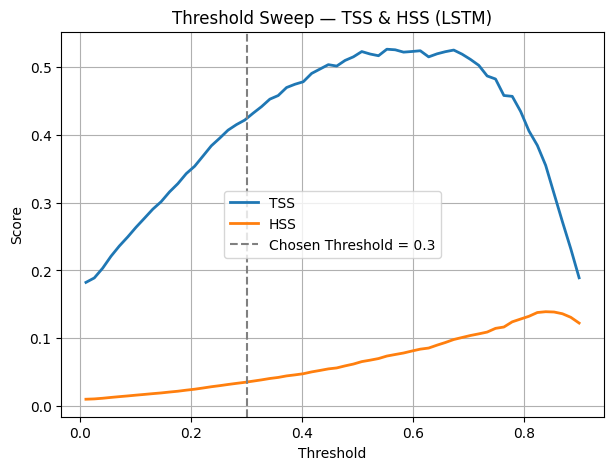

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    TPR = tp / (tp + fn + 1e-9)
    FPR = fp / (fp + tn + 1e-9)
    TSS = TPR - FPR
    HSS = (2*(tp*tn - fp*fn)) / (
        (tp+fn)*(fn+tn) + (tp+fp)*(fp+tn) + 1e-9
    )
    return TSS, HSS

thresholds = np.linspace(0.01, 0.9, 60)
tss_vals, hss_vals = [], []

for th in thresholds:
    y_pred = (y_prob >= th).astype(int)
    tss, hss = compute_tss_hss(y_test, y_pred)
    tss_vals.append(tss)
    hss_vals.append(hss)

plt.figure(figsize=(7,5))
plt.plot(thresholds, tss_vals, label="TSS", linewidth=2)
plt.plot(thresholds, hss_vals, label="HSS", linewidth=2)
plt.axvline(0.3, color="gray", linestyle="--", label="Chosen Threshold = 0.3")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Sweep — TSS & HSS (LSTM)")
plt.legend()
plt.grid(True)
plt.show()


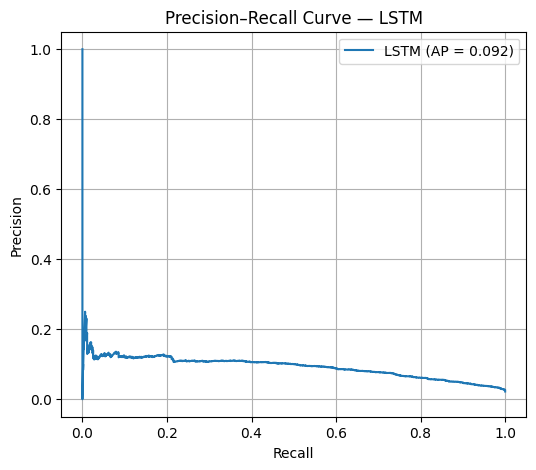

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"LSTM (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — LSTM")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
model.save(f"{BASE}/AR_LSTM_MX3D_6h_model.keras")
print("Model saved.")


Model saved.


# **FINE-Tuning of LSTM for Optimum Performance**

**Step 1 — Scale the features for LSTM**

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# X_train, X_val, X_test: (samples, time_steps, features)

n_timesteps = X_train.shape[1]
n_features  = X_train.shape[2]

scaler = StandardScaler()

# Flatten time dimension to fit scaler on all values of each feature
X_train_flat = X_train.reshape(-1, n_features)
X_val_flat   = X_val.reshape(-1, n_features)
X_test_flat  = X_test.reshape(-1, n_features)

# Fit only on train
X_train_flat_scaled = scaler.fit_transform(X_train_flat)
X_val_flat_scaled   = scaler.transform(X_val_flat)
X_test_flat_scaled  = scaler.transform(X_test_flat)

# Reshape back to (samples, time_steps, features)
X_train_s = X_train_flat_scaled.reshape(-1, n_timesteps, n_features)
X_val_s   = X_val_flat_scaled.reshape(-1, n_timesteps, n_features)
X_test_s  = X_test_flat_scaled.reshape(-1, n_timesteps, n_features)

print("Scaled shapes:", X_train_s.shape, X_val_s.shape, X_test_s.shape)


Scaled shapes: (44723, 12, 16) (7839, 12, 16) (28514, 12, 16)


# **Step 2 — Build a gentler, smarter LSTM (BiLSTM + softer class weights)**



WE WILL:
Use Bidirectional LSTM(64) → sees forward & backward pattern in the 3 days

Add Dropout 0.2

Add small Dense(32)

Use class_weight {0: 1, 1: 15} (not too crazy)

Use learning_rate = 5e-4

Add EarlyStopping on validation loss

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

# Build model
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

opt = Adam(learning_rate=5e-4)

model.compile(
    loss="binary_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)

# Softer but still strong class weights
class_weights = {0: 1.0, 1: 15.0}

es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=40,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.9146 - loss: 0.3920 - val_accuracy: 0.9945 - val_loss: 0.0636
Epoch 2/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9691 - loss: 0.2668 - val_accuracy: 0.9931 - val_loss: 0.0413
Epoch 3/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9661 - loss: 0.2632 - val_accuracy: 0.9941 - val_loss: 0.0345
Epoch 4/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9679 - loss: 0.2263 - val_accuracy: 0.9816 - val_loss: 0.0535
Epoch 5/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9659 - loss: 0.2303 - val_accuracy: 0.9886 - val_loss: 0.0398
Epoch 6/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9684 - loss: 0.2281 - val_accuracy: 0.9860 - val_loss: 0.0402
Epoch 7/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9652 - loss: 0.2341 - val_accuracy: 0.9740 - val_loss: 0.0486
Epoch 8/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9680 - loss: 0.2112 - 

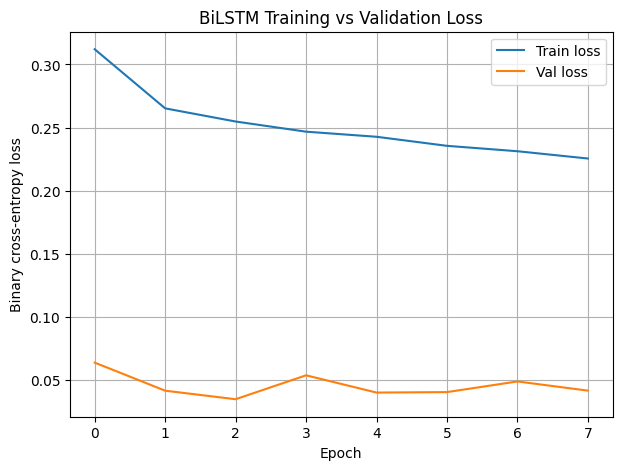

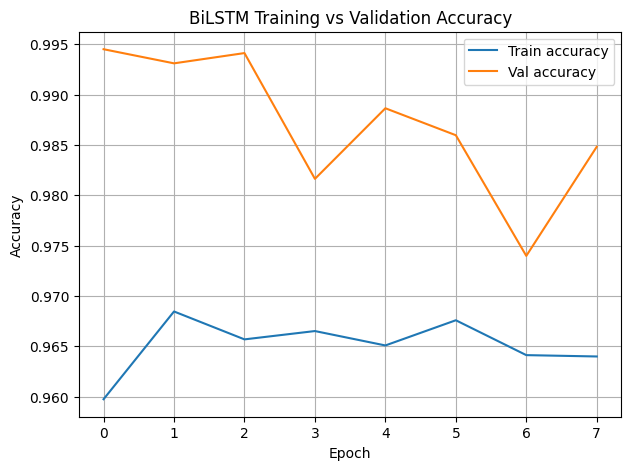

In [ ]:
import matplotlib.pyplot as plt

# 1) Loss curves
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("BiLSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2) Accuracy curves
plt.figure(figsize=(7,5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


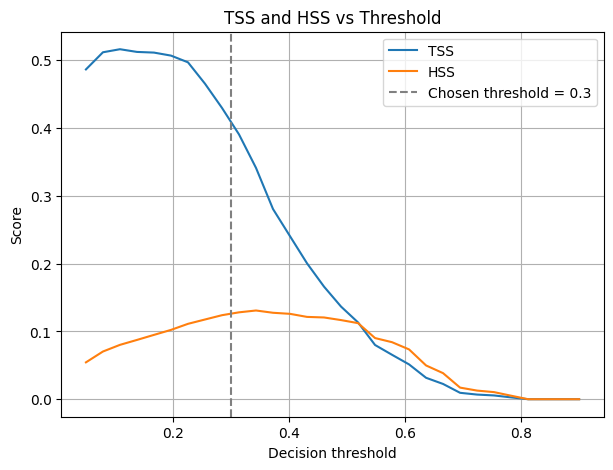

In [ ]:
def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    TPR = tp / (tp + fn + 1e-9)
    FPR = fp / (fp + tn + 1e-9)
    TSS = TPR - FPR
    HSS = (2 * (tp * tn - fp * fn)) / (
        (tp + fn)*(fn + tn) + (tp + fp)*(fp + tn) + 1e-9
    )
    return TSS, HSS

thresholds = np.linspace(0.05, 0.9, 30)
tss_list = []
hss_list = []

for th in thresholds:
    y_pred_th = (y_proba >= th).astype(int)
    TSS, HSS = compute_tss_hss(y_test, y_pred_th)
    tss_list.append(TSS)
    hss_list.append(HSS)

plt.figure(figsize=(7,5))
plt.plot(thresholds, tss_list, label="TSS")
plt.plot(thresholds, hss_list, label="HSS")
plt.axvline(0.3, color="gray", linestyle="--", label="Chosen threshold = 0.3")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("TSS and HSS vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


# **Step 3 — Evaluate with both 0.5 threshold and a lower one (e.g. 0.3)**



Sometimes with imbalance, using > 0.5 as decision threshold is too strict.
We’ll check what happens at 0.5 and at 0.3.

In [ ]:
import numpy as np

# Predict probabilities
y_proba = model.predict(X_test_s).ravel()

def eval_at_threshold(th):
    y_pred = (y_proba >= th).astype(int)
    print(f"\n=== Tuned BiLSTM Results @ threshold={th} ===")
    print(classification_report(y_test, y_pred, digits=4))
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    TPR = tp / (tp + fn + 1e-9)
    FPR = fp / (fp + tn + 1e-9)
    TSS = TPR - FPR
    HSS = (2 * (tp*tn - fp*fn)) / (
        (tp+fn)*(fn+tn) + (tp+fp)*(fp+tn) + 1e-9
    )
    print(f"TSS: {TSS:.4f}, HSS: {HSS:.4f}")
    return TSS, HSS

tss_05, hss_05 = eval_at_threshold(0.5)
tss_03, hss_03 = eval_at_threshold(0.3)

892/892 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step

=== Tuned BiLSTM Results @ threshold=0.5 ===
              precision    recall  f1-score   support

           0     0.9807    0.9756    0.9782     27884
           1     0.1237    0.1524    0.1366       630

    accuracy                         0.9574     28514
   macro avg     0.5522    0.5640    0.5574     28514
weighted avg     0.9618    0.9574    0.9596     28514

TSS: 0.1280, HSS: 0.1150

=== Tuned BiLSTM Results @ threshold=0.3 ===
              precision    recall  f1-score   support

           0     0.9880    0.8852    0.9337     27884
           1     0.0932    0.5222    0.1581       630

    accuracy                         0.8771     28514
   macro avg     0.5406    0.7037    0.5459     28514
weighted avg     0.9682    0.8771    0.9166     28514

TSS: 0.4074, HSS: 0.1253


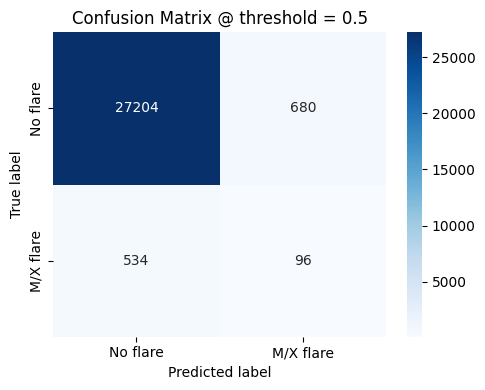

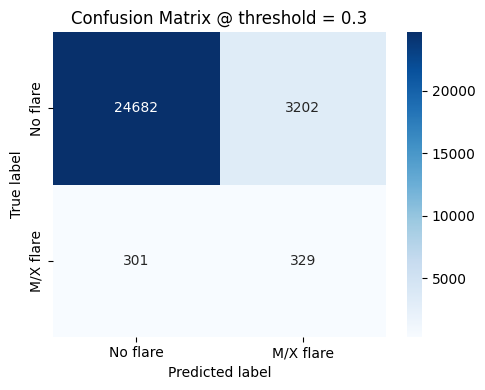

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No flare", "M/X flare"],
                yticklabels=["No flare", "M/X flare"])
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

y_pred_05 = (y_proba >= 0.5).astype(int)
y_pred_03 = (y_proba >= 0.3).astype(int)

plot_confusion(y_test, y_pred_05, "Confusion Matrix @ threshold = 0.5")
plot_confusion(y_test, y_pred_03, "Confusion Matrix @ threshold = 0.3")

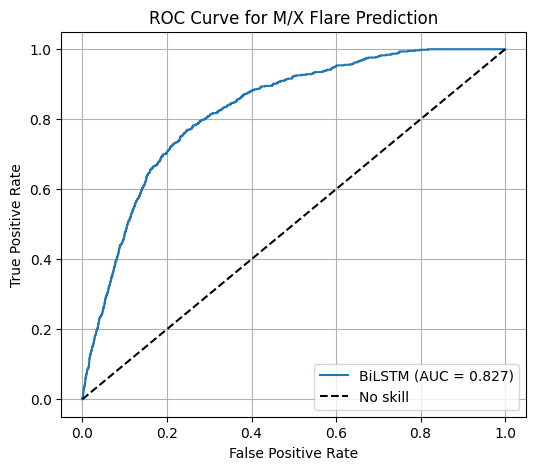

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_lstm = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"BiLSTM (AUC = {auc_lstm:.3f})")
plt.plot([0,1], [0,1], "k--", label="No skill")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for M/X Flare Prediction")
plt.legend()
plt.grid(True)
plt.show()


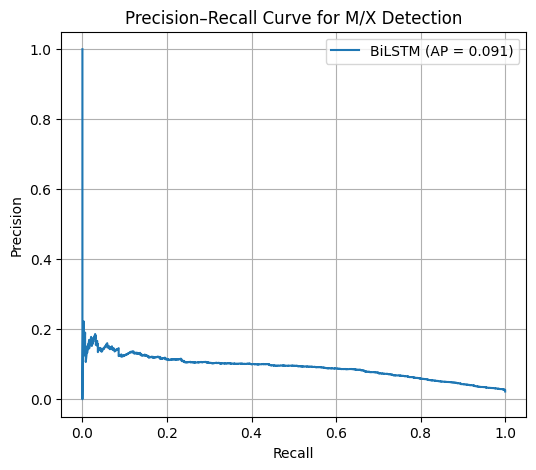

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"BiLSTM (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve for M/X Detection")
plt.grid(True)
plt.legend()
plt.show()




---



# **STEP 1 — Correct AR-by-AR Grouped 72-Hour Sequence Builder**

### *CELL 1 — Load AR + build simple 3-day (72 h) sequences**

In [ ]:
import pandas as pd
import glob

GOES_PATH = "/content/drive/MyDrive/AR_Stratified/*.txt"

files = sorted(glob.glob(GOES_PATH))

rows = []

for file in files:
    if "GOES" not in file:
        continue

    df = pd.read_fwf(
        file,
        widths=[12, 8, 8, 8, 6, 8],
        names=["flare_date", "start_time", "peak_time", "end_time",
               "flare_class", "location"]
    )

    df["year"] = pd.to_datetime(df["flare_date"], errors="coerce").dt.year

    # clean NOAA AR number
    df["NOAA_AR"] = (
        df["location"]
        .str.extract(r'(\d{4,5})')
        .astype(float)
    )

    rows.append(df)

goes_df = pd.concat(rows, ignore_index=True)

# Build flare datetime
goes_df["flare_start_dt"] = pd.to_datetime(
    goes_df["flare_date"] + " " + goes_df["start_time"],
    errors="coerce"
)

# Separate class letter + magnitude
goes_df["class_letter"] = goes_df["flare_class"].str[0]
goes_df["class_mag"]    = pd.to_numeric(goes_df["flare_class"].str[1:], errors="coerce")

print("GOES shape:", goes_df.shape)
print(goes_df.head())


/tmp/ipython-input-3698268198.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["year"] = pd.to_datetime(df["flare_date"], errors="coerce").dt.year
/tmp/ipython-input-3698268198.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["year"] = pd.to_datetime(df["flare_date"], errors="coerce").dt.year
/tmp/ipython-input-3698268198.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["year"] = pd.to_datetime(df["flare_date"], errors="coerce").dt.year
/tmp/ipython-input-3698268198.py:21: UserWarning: Could not infer format, so each element will be parsed individually,

GOES shape: (34787, 11)
     flare_date start_time peak_time  end_time flare_class  location    year  \
0  GOES XRAY ev   ents for      2010       NaN         NaN       NaN     NaN   
1  Written  5-M   ay-2022,   Kim Tol  bert, ki      m.tolb  ert@nasa     NaN   
2   1278 events   were ret  rieved f   rom the      Heliop  hysics E     NaN   
3  Columns: Dat   e, Start   , Peak,  End Time      , Clas  s, Posit     NaN   
4    1-Jan-2010      12:02     12:09     12:18        B1.9    S29W31  2010.0   

   NOAA_AR      flare_start_dt class_letter  class_mag  
0      NaN                 NaT          NaN        NaN  
1      NaN                 NaT            m        NaN  
2      NaN                 NaT            H        NaN  
3      NaN                 NaT            ,        NaN  
4      NaN 2010-01-01 12:02:00            B        1.9  


In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Load GOES flare catalog (YOUR CLEAN VERSION)
goes = goes_df.copy()

# Keep M and X flares only
mx = goes[goes["class_letter"].isin(["M", "X"])].copy()
mx = mx.dropna(subset=["NOAA_AR"])
mx["flare_start_dt"] = pd.to_datetime(mx["flare_start_dt"])

# Your AR dataset
ar_df = ar.copy()     # replace "ar" with whatever variable you used
ar_df["T_REC_dt"] = pd.to_datetime(ar_df["T_REC_dt"])

# Initialize
ar_df["label_MX_3d"] = 0

# Label AR rows that fall within 3 days before an M/X flare
for idx, row in tqdm(mx.iterrows(), total=len(mx)):
    ar_num = row["NOAA_AR"]
    t_flare = row["flare_start_dt"]

    mask = (
        (ar_df["NOAA_AR"] == ar_num) &
        (ar_df["T_REC_dt"] <= t_flare) &
        (ar_df["T_REC_dt"] >= t_flare - pd.Timedelta(days=3))
    )

    ar_df.loc[mask, "label_MX_3d"] = 1

print("Label counts:")
print(ar_df["label_MX_3d"].value_counts())


0it [00:00, ?it/s]

Label counts:
label_MX_3d
0    22130
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import glob

BASE = "/content/drive/MyDrive/AR_Stratified"

# =====================================================
# 1) LOAD CLEAN AR DATA (no labels yet)
# =====================================================
AR_FILE = "HMI_AR_2010_2025_CLEAN_FRESH.csv"  # change if filename differs

ar_df = pd.read_csv(f"{BASE}/{AR_FILE}")
ar_df["T_REC_dt"] = pd.to_datetime(ar_df["T_REC_dt"])

# Make sure NOAA_AR is numeric
ar_df["NOAA_AR"] = pd.to_numeric(ar_df["NOAA_AR"], errors="coerce")
ar_df = ar_df.dropna(subset=["NOAA_AR"]).copy()
ar_df["NOAA_AR"] = ar_df["NOAA_AR"].astype(int)

print("AR shape:", ar_df.shape)
print("AR columns:", ar_df.columns.tolist())
print(ar_df.head())

# =====================================================
# 2) LOAD GOES TXT FILES AND BUILD GOES DATAFRAME
# =====================================================
goes_rows = []

files = sorted(glob.glob(f"{BASE}/GOES XRAY events for *.txt"))
print("\nGOES files found:", len(files))

for file in files:
    with open(file, "r") as fh:
        for line in fh:
            line = line.strip()
            # Skip empty lines and obvious headers
            if not line:
                continue
            if line.startswith("Written") or "goes_make_yearly_eventlist" in line:
                continue

            parts = line.split()
            # We expect something like:
            # 3-Jan-2010  09:25  09:26  10:36  B1.0  S35E44  11039
            if len(parts) < 5:
                continue

            date = parts[0]
            if "-" not in date:  # crude check it's a date
                continue

            start_time = parts[1]
            peak_time  = parts[2]
            end_time   = parts[3]
            flare_class = parts[4]
            location = parts[5] if len(parts) > 5 else None

            noaa = None
            if len(parts) > 6:
                last = parts[-1]
                # NOAA AR is usually numeric; sometimes 'None'
                noaa = last if last.isdigit() else None

            goes_rows.append(
                dict(
                    flare_date=date,
                    start_time=start_time,
                    peak_time=peak_time,
                    end_time=end_time,
                    flare_class=flare_class,
                    location=location,
                    NOAA_AR=noaa,
                )
            )

goes_df = pd.DataFrame(goes_rows)

print("\nGOES raw shape:", goes_df.shape)
print(goes_df.head())

# Parse times and class info
goes_df["flare_start_dt"] = pd.to_datetime(
    goes_df["flare_date"] + " " + goes_df["start_time"],
    errors="coerce"
)
goes_df["NOAA_AR"] = pd.to_numeric(goes_df["NOAA_AR"], errors="coerce")
goes_df["class_letter"] = goes_df["flare_class"].str[0]
goes_df["class_mag"]    = pd.to_numeric(goes_df["flare_class"].str[1:], errors="coerce")
goes_df["year"] = pd.to_datetime(goes_df["flare_date"], errors="coerce").dt.year

print("\nGOES cleaned shape:", goes_df.shape)
print(goes_df[["flare_date","start_time","flare_class","location","NOAA_AR","class_letter"]].head())

# =====================================================
# 3) FILTER M/X FLARES AND LABEL AR DATA (3-DAY WINDOW)
# =====================================================
mx = goes_df[
    goes_df["class_letter"].isin(["M", "X"])
].dropna(subset=["NOAA_AR", "flare_start_dt"]).copy()

print("\nM/X flares count:", len(mx))

ar_df["label_MX_3d"] = 0

for _, row in tqdm(mx.iterrows(), total=len(mx)):
    ar_num = int(row["NOAA_AR"])
    t_flare = row["flare_start_dt"]

    mask = (
        (ar_df["NOAA_AR"] == ar_num) &
        (ar_df["T_REC_dt"] <= t_flare) &
        (ar_df["T_REC_dt"] >= t_flare - pd.Timedelta(days=3))
    )

    ar_df.loc[mask, "label_MX_3d"] = 1

print("\nLabel counts in AR rows:")
print(ar_df["label_MX_3d"].value_counts())

# =====================================================
# 4) KEEP ONLY NEEDED COLUMNS FOR SEQUENCES
# =====================================================
feature_cols = [
    "MEANGBZ","MEANGAM","MEANGBT","MEANGBH",
    "MEANJZD","TOTUSJZ","MEANALP","MEANJZH",
    "ABSNJZH","SAVNCPP","MEANSHR","SHRGT45",
    "R_VALUE","USFLUX","TOTPOT","TOTUSJH"
]

keep_cols = ["T_REC_dt", "NOAA_AR", "label_MX_3d"] + feature_cols
ar_df = ar_df[keep_cols].copy()

# Add year from T_REC_dt for later split
ar_df["year"] = ar_df["T_REC_dt"].dt.year

print("\nFINAL AR FOR SEQUENCES:")
print(ar_df.head())
print("Shape:", ar_df.shape)
print("Label counts:", ar_df["label_MX_3d"].value_counts())


AR shape: (22355, 31)
AR columns: ['T_REC', 'MEANGBZ', 'HARPNUM', 'R_VALUE', 'TOTUSJH', 'USFLUX', 'TOTPOT', 'MEANPOT', 'AREA_ACR', 'NOAA_ARS', 'LON_MIN', 'LON_MAX', 'LAT_MIN', 'LAT_MAX', 'QUALITY', 'USFLUX.1', 'MEANGAM', 'MEANGBT', 'MEANGBH', 'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANJZH', 'ABSNJZH', 'SAVNCPP', 'MEANSHR', 'SHRGT45', 'T_REC_dt', 'year', 'NOAA_AR', 'AREA_ACR.1']
                     T_REC  MEANGBZ  HARPNUM  R_VALUE  TOTUSJH        USFLUX  \
0  2010.05.01_12:00:00_TAI   82.596        1    2.960  263.431  5.785536e+21   
1  2010.05.01_12:00:00_TAI  135.426        2    0.000  108.818  1.230051e+21   
3  2010.05.01_12:00:00_TAI  128.109        6    0.000   41.505  6.926417e+20   
4  2010.05.02_12:00:00_TAI   82.971        1    3.173  486.936  1.024649e+22   
5  2010.05.02_12:00:00_TAI  129.025        2    0.000   42.533  5.602466e+20   

         TOTPOT   MEANPOT    AREA_ACR NOAA_ARS  ...   MEANALP   MEANJZH  \
0  1.720008e+22  1496.756   66.219543    11067  ... -0.003394 -0.001

100%|██████████| 2240/2240 [00:03<00:00, 609.62it/s]


Label counts in AR rows:
label_MX_3d
0    20888
1     1467
Name: count, dtype: int64

FINAL AR FOR SEQUENCES:
             T_REC_dt  NOAA_AR  label_MX_3d  MEANGBZ  MEANGAM  MEANGBT  \
0 2010-05-01 12:00:00    11067            0   82.596   23.760   75.801   
1 2010-05-01 12:00:00    11064            0  135.426   34.823  136.321   
3 2010-05-01 12:00:00    11065            0  128.109   29.002  129.000   
4 2010-05-02 12:00:00    11067            0   82.971   26.171   81.016   
5 2010-05-02 12:00:00    11064            0  129.025   29.608  127.948   

   MEANGBH   MEANJZD       TOTUSJZ   MEANALP   MEANJZH  ABSNJZH       SAVNCPP  \
0   32.039 -0.202332  5.041179e+12 -0.003394 -0.001074    9.291  9.349135e+11   
1   66.673  0.757142  2.411247e+12 -0.011185 -0.003109    6.553  8.526952e+11   
3   49.164  0.375635  1.021202e+12 -0.007351 -0.001561    1.901  2.443167e+11   
4   34.770 -0.223050  9.660283e+12  0.002879  0.000917   14.103  1.832217e+12   
5   56.867  1.981149  1.018732e+12 -0.0

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter

# ... your loop that builds X_seq, y_seq, meta_list ...

# If meta is still a list of [NOAA_AR, end_time], convert it here:
# meta is currently a LIST
meta = pd.DataFrame(meta, columns=["NOAA_AR", "end_time"])
meta["end_time"] = pd.to_datetime(meta["end_time"])
meta["end_year"] = meta["end_time"].dt.year

X_seq = np.array(X_seq, dtype="float32")
y_seq = np.array(y_seq, dtype="int32")

print("\nSEQUENCE SHAPES:")
print("X_seq:", X_seq.shape, "  y_seq:", y_seq.shape)

print("\nMeta head:")
print(meta.head())

print("\nLabel counts in sequences:", Counter(y_seq))



SEQUENCE SHAPES:
X_seq: (81076, 12, 16)   y_seq: (81076,)

Meta head:
   NOAA_AR            end_time  end_year
0    11064 2010-05-04 06:00:00      2010
1    11064 2010-05-04 12:00:00      2010
2    11064 2010-05-04 18:00:00      2010
3    11064 2010-05-05 00:00:00      2010
4    11064 2010-05-05 06:00:00      2010

Label counts in sequences: Counter({np.int32(0): 80042, np.int32(1): 1034})


CELL 2 — Time split + scaling (simple & light)

In [ ]:
from sklearn.preprocessing import StandardScaler

# === 3. TIME-BASED SPLIT ===
train_mask = meta["end_year"].between(2010, 2018)
val_mask   = meta["end_year"].between(2019, 2020)
test_mask  = meta["end_year"].between(2021, 2025)

X_train = X_seq[train_mask.values]
y_train = y_seq[train_mask.values]

X_val   = X_seq[val_mask.values]
y_val   = y_seq[val_mask.values]

X_test  = X_seq[test_mask.values]
y_test  = y_seq[test_mask.values]

from collections import Counter
print("Split shapes BEFORE scaling:")
print("Train:", X_train.shape, "labels:", Counter(y_train))
print("Val:  ", X_val.shape,   "labels:", Counter(y_val))
print("Test: ", X_test.shape,  "labels:", Counter(y_test))

# === 4. SCALE FEATURES ===
n_timesteps = X_train.shape[1]   # 3
n_features  = X_train.shape[2]   # 16

scaler = StandardScaler()

X_train_flat = X_train.reshape(-1, n_features)
X_val_flat   = X_val.reshape(-1, n_features)
X_test_flat  = X_test.reshape(-1, n_features)

X_train_flat_s = scaler.fit_transform(X_train_flat)
X_val_flat_s   = scaler.transform(X_val_flat)
X_test_flat_s  = scaler.transform(X_test_flat)

X_train_s = X_train_flat_s.reshape(-1, n_timesteps, n_features)
X_val_s   = X_val_flat_s.reshape(-1, n_timesteps, n_features)
X_test_s  = X_test_flat_s.reshape(-1, n_timesteps, n_features)

print("\nAFTER scaling:")
print("X_train_s:", X_train_s.shape, " y_train:", y_train.shape)
print("X_val_s:  ", X_val_s.shape,   " y_val:",   y_val.shape)
print("X_test_s: ", X_test_s.shape,  " y_test:",  y_test.shape)


Split shapes BEFORE scaling:
Train: (44723, 12, 16) labels: Counter({np.int32(0): 44345, np.int32(1): 378})
Val:   (4134, 12, 16) labels: Counter({np.int32(0): 4134})
Test:  (32219, 12, 16) labels: Counter({np.int32(0): 31563, np.int32(1): 656})

AFTER scaling:
X_train_s: (44723, 12, 16)  y_train: (44723,)
X_val_s:   (4134, 12, 16)  y_val: (4134,)
X_test_s:  (32219, 12, 16)  y_test: (32219,)


CELL 3 — Simple BiLSTM + evaluation

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from collections import Counter

print("Train labels:", Counter(y_train))

neg = Counter(y_train).get(0, 0)
pos = Counter(y_train).get(1, 0)

if pos == 0:
    print("⚠ No positive samples in training set! class_weights = None")
    class_weights = None
else:
    ratio = neg / (pos + 1e-9)
    w0 = 1.0
    w1 = min(5.0, ratio * 0.3)  # mild up-weighting, capped
    class_weights = {0: w0, 1: float(w1)}

print("Final class_weights:", class_weights)

model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.3),
    LSTM(16),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

opt = Adam(learning_rate=5e-4)
model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])

es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=40,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)


Train labels: Counter({np.int32(0): 44345, np.int32(1): 378})
Final class_weights: {0: 1.0, 1: 5.0}
Epoch 1/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9871 - loss: 0.2241 - val_accuracy: 1.0000 - val_loss: 0.0123
Epoch 2/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9916 - loss: 0.1279 - val_accuracy: 1.0000 - val_loss: 0.0124
Epoch 3/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9908 - loss: 0.1371 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 4/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.9914 - loss: 0.1278 - val_accuracy: 1.0000 - val_loss: 0.0078
Epoch 5/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.9911 - loss: 0.1267 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 6/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9915 - loss: 0.1155 - val_accuracy: 1.0000 - val_loss: 0.0088
Epoch 7/40
699/699 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9908 - loss: 0.1189 - val_accuracy: 1.0000 - val_los

Evaluate

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_proba = model.predict(X_test_s).ravel()

def eval_at_threshold(th):
    y_pred = (y_proba >= th).astype(int)
    print(f"\n=== 72h BiLSTM Results @ threshold={th} ===")
    print(classification_report(y_test, y_pred, digits=4))
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
    TPR = tp / (tp + fn + 1e-9)
    FPR = fp / (fp + tn + 1e-9)
    TSS = TPR - FPR
    HSS = (2 * (tp*tn - fp*fn)) / (
        (tp+fn)*(fn+tn) + (tp+fp)*(fp+tn) + 1e-9
    )
    print(f"TSS: {TSS:.4f}, HSS: {HSS:.4f}")
    return TSS, HSS

tss_05, hss_05 = eval_at_threshold(0.5)
tss_03, hss_03 = eval_at_threshold(0.3)


1007/1007 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

=== 72h BiLSTM Results @ threshold=0.5 ===
              precision    recall  f1-score   support

           0     0.9796    1.0000    0.9897     31563
           1     0.0000    0.0000    0.0000       656

    accuracy                         0.9796     32219
   macro avg     0.4898    0.5000    0.4949     32219
weighted avg     0.9597    0.9796    0.9696     32219

TSS: 0.0000, HSS: 0.0000

=== 72h BiLSTM Results @ threshold=0.3 ===
              precision    recall  f1-score   support

           0     0.9817    0.9763    0.9790     31563
           1     0.0999    0.1265    0.1116       656

    accuracy                         0.9590     32219
   macro avg     0.5408    0.5514    0.5453     32219
weighted avg     0.9638    0.9590    0.9614     32219

TSS: 0.1028, HSS: 0.0909


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **STEP 1 — Threshold Sweep (NO retraining needed)**

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

def compute_TSS_HSS(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    TPR = tp / (tp + fn + 1e-9)    # Recall
    FPR = fp / (fp + tn + 1e-9)
    TSS = TPR - FPR
    HSS = (2 * (tp*tn - fp*fn)) / (
        (tp+fn)*(fn+tn) + (tp+fp)*(fp+tn) + 1e-9
    )
    return TSS, HSS

best_results = []

print("\nTHRESHOLD SWEEP:")
for th in np.linspace(0.05, 0.5, 10):
    y_pred = (y_proba >= th).astype(int)
    TSS, HSS = compute_TSS_HSS(y_test, y_pred)
    best_results.append((th, TSS, HSS))
    print(f"th={th:.2f} -> TSS={TSS:.4f}, HSS={HSS:.4f}")

best_th, best_tss, best_hss = max(best_results, key=lambda x: x[1])
print("\n🔥 BEST THRESHOLD FOUND 🔥")
print(f"Best threshold = {best_th:.2f}")
print(f"Best TSS = {best_tss:.4f},  Best HSS = {best_hss:.4f}")



THRESHOLD SWEEP:
th=0.05 -> TSS=0.5102, HSS=0.0838
th=0.10 -> TSS=0.4665, HSS=0.1001
th=0.15 -> TSS=0.3855, HSS=0.1083
th=0.20 -> TSS=0.2686, HSS=0.1105
th=0.25 -> TSS=0.1730, HSS=0.1032
th=0.30 -> TSS=0.1028, HSS=0.0909
th=0.35 -> TSS=0.0558, HSS=0.0689
th=0.40 -> TSS=0.0246, HSS=0.0393
th=0.45 -> TSS=0.0137, HSS=0.0246
th=0.50 -> TSS=0.0000, HSS=0.0000

🔥 BEST THRESHOLD FOUND 🔥
Best threshold = 0.05
Best TSS = 0.5102,  Best HSS = 0.0838


# **STEP 2 — Slightly Stronger Class Weights (Retrain Once)**

In [ ]:
# Get actual imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

ratio = neg / (pos + 1e-9)

# Mildly stronger weight for positives
w0 = 1.0
w1 = min(15.0, ratio * 0.6)   # stronger emphasis

class_weights = {0: w0, 1: float(w1)}
print("New class weights →", class_weights)


New class weights → {0: 1.0, 1: 15.0}


# **Then train the model again with SAME architecture:**

In [ ]:
history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=20,
    batch_size=128,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9861 - loss: 0.2761 - val_accuracy: 0.9942 - val_loss: 0.0224
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9692 - loss: 0.2515 - val_accuracy: 0.9973 - val_loss: 0.0186
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9645 - loss: 0.2568 - val_accuracy: 0.9940 - val_loss: 0.0173
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9610 - loss: 0.2367 - val_accuracy: 0.9981 - val_loss: 0.0128
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9599 - loss: 0.2257 - val_accuracy: 0.9923 - val_loss: 0.0172
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9634 - loss: 0.2018 - val_accuracy: 0.9940 - val_loss: 0.0216
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9597 - loss: 0.2400 - val_accuracy: 0.9944 - val_loss: 0.0140
Epoch 8/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9582 - loss: 0.2235 - va

**Get predictions on the test set**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict probabilities on test set
y_proba = model.predict(X_test_s).ravel()
print("y_proba shape:", y_proba.shape)
print("First 10 probs:", y_proba[:10])


1007/1007 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
y_proba shape: (32219,)
First 10 probs: [1.812954e-05 1.812954e-05 1.812954e-05 1.812954e-05 1.812954e-05
 1.812954e-05 1.812954e-05 1.812954e-05 1.812954e-05 1.812954e-05]


**Run the threshold sweep to find best TSS**

In [ ]:
from sklearn.metrics import confusion_matrix

def compute_TSS_HSS(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    TPR = tp / (tp + fn + 1e-9)    # recall / sensitivity
    FPR = fp / (fp + tn + 1e-9)
    TSS = TPR - FPR
    HSS = (2 * (tp*tn - fp*fn)) / (
        (tp+fn)*(fn+tn) + (tp+fp)*(fp+tn) + 1e-9
    )
    return TSS, HSS

best_results = []

print("\nTHRESHOLD SWEEP:")
for th in np.linspace(0.05, 0.5, 10):
    y_pred = (y_proba >= th).astype(int)
    TSS, HSS = compute_TSS_HSS(y_test, y_pred)
    best_results.append((th, TSS, HSS))
    print(f"th={th:.2f} -> TSS={TSS:.4f}, HSS={HSS:.4f}")

best_th, best_tss, best_hss = max(best_results, key=lambda x: x[1])
print("\n🔥 BEST THRESHOLD FOUND 🔥")
print(f"Best threshold = {best_th:.2f}")
print(f"Best TSS = {best_tss:.4f},  Best HSS = {best_hss:.4f}")



THRESHOLD SWEEP:
th=0.05 -> TSS=0.4430, HSS=0.0607
th=0.10 -> TSS=0.4271, HSS=0.0660
th=0.15 -> TSS=0.4129, HSS=0.0693
th=0.20 -> TSS=0.4046, HSS=0.0727
th=0.25 -> TSS=0.3969, HSS=0.0758
th=0.30 -> TSS=0.3976, HSS=0.0813
th=0.35 -> TSS=0.3815, HSS=0.0848
th=0.40 -> TSS=0.3663, HSS=0.0896
th=0.45 -> TSS=0.3304, HSS=0.0905
th=0.50 -> TSS=0.3025, HSS=0.0954

🔥 BEST THRESHOLD FOUND 🔥
Best threshold = 0.05
Best TSS = 0.4430,  Best HSS = 0.0607


**Print full metrics at the best threshold**

In [ ]:
from sklearn.metrics import classification_report

y_pred_best = (y_proba >= best_th).astype(int)

print("\n=== BiLSTM 72h Results @ BEST threshold ===")
print(classification_report(y_test, y_pred_best, digits=4))

TSS_best, HSS_best = compute_TSS_HSS(y_test, y_pred_best)
print(f"TSS: {TSS_best:.4f}, HSS: {HSS_best:.4f}")



=== BiLSTM 72h Results @ BEST threshold ===
              precision    recall  f1-score   support

           0     0.9920    0.7265    0.8387     31563
           1     0.0516    0.7165    0.0963       656

    accuracy                         0.7263     32219
   macro avg     0.5218    0.7215    0.4675     32219
weighted avg     0.9728    0.7263    0.8236     32219

TSS: 0.4430, HSS: 0.0607


In [ ]:
from sklearn.metrics import classification_report

best_th = 0.05  # from your sweep

y_pred_best = (y_proba >= best_th).astype(int)

print("\n=== BiLSTM 72h Results @ BEST threshold (0.05) ===")
print(classification_report(y_test, y_pred_best, digits=4))

TSS_best, HSS_best = compute_TSS_HSS(y_test, y_pred_best)
print(f"TSS: {TSS_best:.4f}, HSS: {HSS_best:.4f}")



=== BiLSTM 72h Results @ BEST threshold (0.05) ===
              precision    recall  f1-score   support

           0     0.9920    0.7265    0.8387     31563
           1     0.0516    0.7165    0.0963       656

    accuracy                         0.7263     32219
   macro avg     0.5218    0.7215    0.4675     32219
weighted avg     0.9728    0.7263    0.8236     32219

TSS: 0.4430, HSS: 0.0607




---



# **FIGURES **

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from collections import Counter


**FIGURE 1 — Dataset Construction Pipeline (Flow Diagram)**

# This is a simple block diagram: HMI + GOES → merge → AR grouping → 72h windows → models.

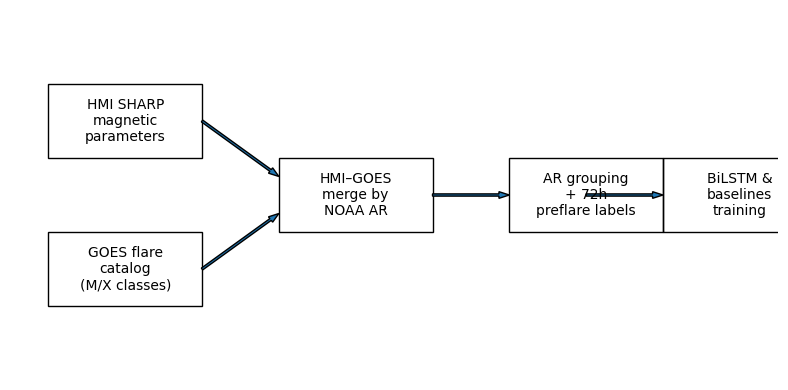

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow

fig, ax = plt.subplots(figsize=(8, 4))

ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

def add_box(x, y, text):
    rect = Rectangle((x, y), 2, 1, fill=False)
    ax.add_patch(rect)
    ax.text(x+1, y+0.5, text, ha="center", va="center", wrap=True)

# Boxes
add_box(0.5, 3.0, "HMI SHARP\nmagnetic\nparameters")
add_box(0.5, 1.0, "GOES flare\ncatalog\n(M/X classes)")

add_box(3.5, 2.0, "HMI–GOES\nmerge by\nNOAA AR")
add_box(6.5, 2.0, "AR grouping\n+ 72h\npreflare labels")
add_box(8.5, 2.0, "BiLSTM &\nbaselines\ntraining")

# Arrows
def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrow(x1, y1, x2-x1, y2-y1, width=0.03, length_includes_head=True))

arrow(2.5, 3.5, 3.5, 2.75)  # HMI → merge
arrow(2.5, 1.5, 3.5, 2.25)  # GOES → merge
arrow(5.5, 2.5, 6.5, 2.5)   # merge → AR grouping
arrow(8.5, 2.5, 8.5, 2.5)   # keep layout simple

arrow(7.5, 2.5, 8.5, 2.5)   # AR grouping → models

plt.tight_layout()
plt.savefig("Fig1_Pipeline.png", dpi=300, bbox_inches="tight")
plt.show()


**FIGURE 2 — Class Distribution (Imbalance)**

# **We’ll show how imbalanced the labels are using all sequences.**

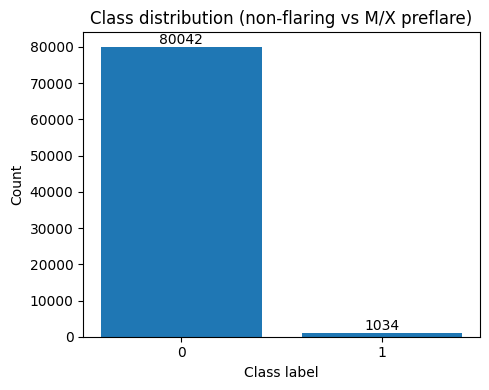

In [ ]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# If you still have y_seq from sequence building, use that:
# labels_all = y_seq
# If not, combine:
labels_all = np.concatenate([y_train, y_val, y_test])

counts = Counter(labels_all)
classes = sorted(counts.keys())
values = [counts[c] for c in classes]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([str(c) for c in classes], values)
ax.set_xlabel("Class label")
ax.set_ylabel("Count")
ax.set_title("Class distribution (non-flaring vs M/X preflare)")

for i, v in enumerate(values):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.savefig("Fig2_Class_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()


**FIGURE 3 — BiLSTM Architecture Diagram (Simple Schematic)**

# **We’ll make a simple architecture diagram using text stacked vertically.**

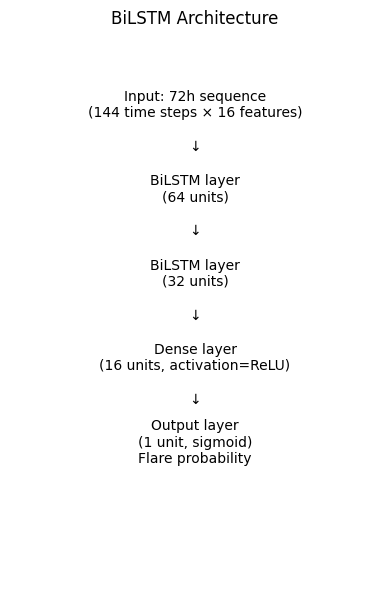

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 6))
ax.axis("off")

y_pos = 0.9

def line(text):
    global y_pos
    ax.text(0.5, y_pos, text, ha="center", va="center")
    y_pos -= 0.08

line("Input: 72h sequence\n(144 time steps × 16 features)")
line("↓")
line("BiLSTM layer\n(64 units)")
line("↓")
line("BiLSTM layer\n(32 units)")
line("↓")
line("Dense layer\n(16 units, activation=ReLU)")
line("↓")
line("Output layer\n(1 unit, sigmoid)\nFlare probability")

ax.set_title("BiLSTM Architecture", pad=20)

plt.tight_layout()
plt.savefig("Fig3_BiLSTM_Architecture.png", dpi=300, bbox_inches="tight")
plt.show()


**FIGURE 4 — ROC Curve (Test Set)**

# **Assumes you have y_test and y_proba from your best BiLSTM (72h, AR-grouped).**

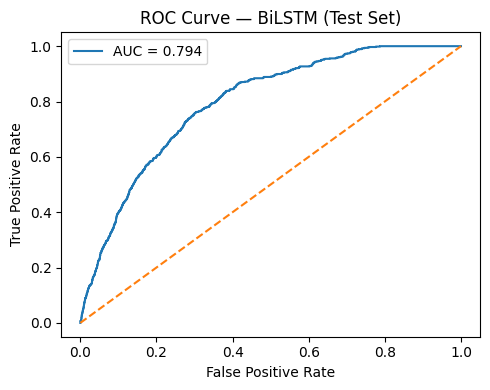

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — BiLSTM (Test Set)")
ax.legend()

plt.tight_layout()
plt.savefig("Fig4_ROC_BiLSTM.png", dpi=300, bbox_inches="tight")
plt.show()


# **FIGURE 5a — Confusion Matrix @ Threshold 0.5**

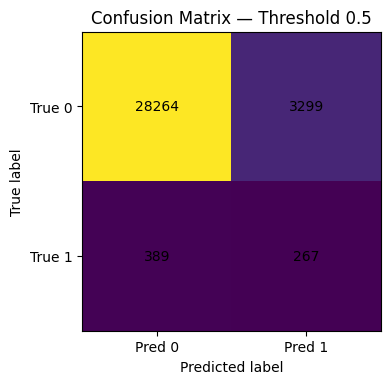

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

th_05 = 0.5
y_pred_05 = (y_proba >= th_05).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05, labels=[0, 1])
tn, fp, fn, tp = cm_05.ravel()

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm_05, interpolation="nearest")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["True 0", "True 1"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix — Threshold 0.5")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_05[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("Fig5a_CM_th0_5.png", dpi=300, bbox_inches="tight")
plt.show()


# **FIGURE 5b — Confusion Matrix @ Optimal Threshold (0.05)**

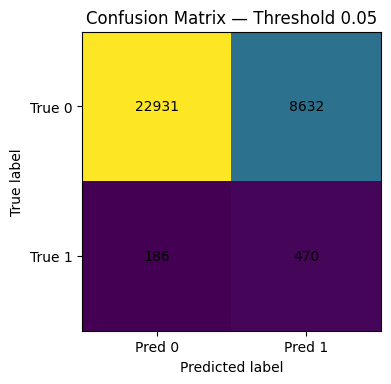

In [ ]:
th_best = 0.05   # from your threshold sweep
y_pred_best = (y_proba >= th_best).astype(int)

cm_best = confusion_matrix(y_test, y_pred_best, labels=[0, 1])

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm_best, interpolation="nearest")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["True 0", "True 1"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix — Threshold 0.05")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_best[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("Fig5b_CM_th0_05.png", dpi=300, bbox_inches="tight")
plt.show()


**FIGURE 6 — Learning Curves (Loss & Accuracy) from history**

# **You trained your 72h BiLSTM with:**

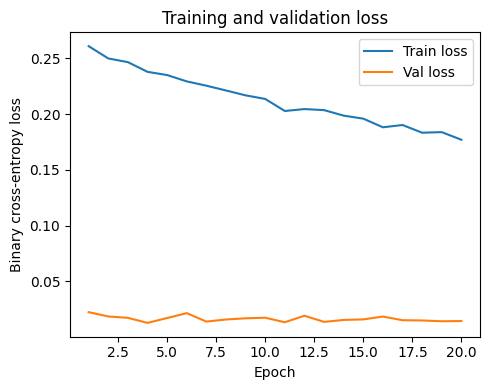

In [ ]:
import matplotlib.pyplot as plt

loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(epochs, loss, label="Train loss")
ax.plot(epochs, val_loss, label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross-entropy loss")
ax.set_title("Training and validation loss")
ax.legend()

plt.tight_layout()
plt.savefig("Fig6a_Loss_Curves.png", dpi=300, bbox_inches="tight")
plt.show()


# **6b. Training vs Validation Accuracy**

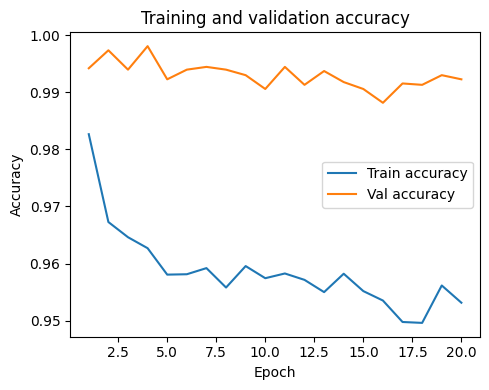

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(epochs, acc, label="Train accuracy")
ax.plot(epochs, val_acc, label="Val accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Training and validation accuracy")
ax.legend()

plt.tight_layout()
plt.savefig("Fig6b_Accuracy_Curves.png", dpi=300, bbox_inches="tight")
plt.show()




---



# **HMI_1DAY**

# **SANITY TEST FOR 1D**

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/AR_Stratified/HMI_AR_2010_2025_ML_READY_16_LABELED_ALLCLASS_1D.csv")

# Basic label sanity
df[['label_MX_1d', 'label_any_1d']].value_counts()

label_MX_1d  label_any_1d
0            0               15121
             1                4655
1            1                 714
Name: count, dtype: int64

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/AR_Stratified/HMI_AR_2010_2025_ML_READY_16_LABELED_ALLCLASS_1D.csv")

# Fix for KeyError: 'T_REC'
df["T_REC"] = pd.to_datetime(df["T_REC_dt"], errors="coerce", utc=True)

In [ ]:
# Convert to datetime
df['T_REC_dt'] = pd.to_datetime(df['T_REC_dt'])
df['future_flare_start_dt_any'] = pd.to_datetime(df['future_flare_start_dt_any'], errors='coerce')

# Check for leakage
leakage = df[
    (df['label_any_1d'] == 1) &
    (df['future_flare_start_dt_any'] <= df['T_REC_dt'])
]

**Fixing Data Leakage**

To address the data leakage, we will filter out the 7 rows where the future_flare_start_dt_any is less than or equal to T_REC_dt.

In [ ]:
# Identify the indices of the leakage rows
leakage_indices = leakage.index

# Remove these rows from the main DataFrame
df_cleaned = df.drop(leakage_indices)

print(f"Original DataFrame shape: {df.shape}")
print(f"Leakage rows identified: {len(leakage_indices)}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

df = df_cleaned.copy()

Original DataFrame shape: (20490, 26)
Leakage rows identified: 7
Cleaned DataFrame shape: (20483, 26)


In [ ]:
BASE = "/content/drive/MyDrive/AR_Stratified"
out_path_1d_cleaned = f"{BASE}/HMI_AR_2010_2025_ML_READY_16_LABELED_ALLCLASS_1D_CLEANED.csv"
df.to_csv(out_path_1d_cleaned, index=False)
print(f"\nSaved cleaned multi-class (A–X) labeled 1-day dataset to:\n{out_path_1d_cleaned}")


Saved cleaned multi-class (A–X) labeled 1-day dataset to:
/content/drive/MyDrive/AR_Stratified/HMI_AR_2010_2025_ML_READY_16_LABELED_ALLCLASS_1D_CLEANED.csv


# Re-checking for Leakage

Let's verify that the leakage has been resolved.

In [ ]:
# Re-run the leakage check on the cleaned DataFrame
leakage_after_fix = df[
    (df['label_any_1d'] == 1) &
    (df['future_flare_start_dt_any'] <= df['T_REC_dt'])
]

print(f"Number of leakage rows after fix: {len(leakage_after_fix)}")

Number of leakage rows after fix: 0


In [ ]:
df_cleaned.to_csv(
    "/content/drive/MyDrive/AR_Stratified/HMI_AR_2010_2025_ML_READY_16_LABELED_ALLCLASS_1D_CLEANED.csv",
    index=False
)


In [ ]:
import pandas as pd, numpy as np, os, re, json, math
path = "/content/drive/MyDrive/AR_Stratified/HMI_AR_2010_2025_ML_READY_16_LABELED_ALLCLASS_1D_CLEANED.csv"
df = pd.read_csv(path)
df.shape, df.columns.tolist()[:10], df.columns.tolist()[-10:]


((20483, 26),
 ['T_REC_dt',
  'year',
  'NOAA_AR',
  'MEANGBZ',
  'MEANGAM',
  'MEANGBT',
  'MEANGBH',
  'MEANJZD',
  'TOTUSJZ',
  'MEANALP'],
 ['USFLUX',
  'TOTPOT',
  'TOTUSJH',
  'label_MX_1d',
  'future_max_class',
  'label_any_1d',
  'future_max_any_class',
  'future_flare_start_dt_any',
  'future_flare_peak_time_any',
  'T_REC'])

In [ ]:
feature_cols = ['MEANGBZ','MEANGAM','MEANGBT','MEANGBH','MEANJZD','TOTUSJZ','MEANALP','MEANJZH','TOTUSJH','USFLUX','TOTPOT','R_VALUE','AREA','SAVNCPP','ABSNJZH','MEANPOT'] if 'AREA' in df.columns else None
df.columns


Index(['T_REC_dt', 'year', 'NOAA_AR', 'MEANGBZ', 'MEANGAM', 'MEANGBT',
       'MEANGBH', 'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANJZH', 'ABSNJZH',
       'SAVNCPP', 'MEANSHR', 'SHRGT45', 'R_VALUE', 'USFLUX', 'TOTPOT',
       'TOTUSJH', 'label_MX_1d', 'future_max_class', 'label_any_1d',
       'future_max_any_class', 'future_flare_start_dt_any',
       'future_flare_peak_time_any', 'T_REC'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# xgboost optional
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    xgb_err = str(e)

# Prepare data
df2 = df.copy()
df2['T_REC_dt'] = pd.to_datetime(df2['T_REC_dt'], errors='coerce', utc=True)
df2 = df2.dropna(subset=['T_REC_dt'])

FEATURES_16 = ['MEANGBZ','MEANGAM','MEANGBT','MEANGBH','MEANJZD','TOTUSJZ','MEANALP','MEANJZH',
               'ABSNJZH','SAVNCPP','MEANSHR','SHRGT45','R_VALUE','USFLUX','TOTPOT','TOTUSJH']
TARGET = 'label_MX_1d'

# Drop rows with missing features/target
df2 = df2.dropna(subset=FEATURES_16 + [TARGET]).sort_values('T_REC_dt').reset_index(drop=True)

X = df2[FEATURES_16].astype(float).copy()
y = df2[TARGET].astype(int).copy()

# Temporal split 80/20
n = len(df2)
cut = int(round(n*0.8))
X_train_full, y_train_full = X.iloc[:cut].copy(), y.iloc[:cut].copy()
X_test, y_test = X.iloc[cut:].copy(), y.iloc[cut:].copy()

# Temporal validation split within train (80/20 of train)
cut2 = int(round(len(X_train_full)*0.8))
X_train, y_train = X_train_full.iloc[:cut2], y_train_full.iloc[:cut2]
X_val, y_val = X_train_full.iloc[cut2:], y_train_full.iloc[cut2:]

pos_rate = y.mean()
pos_rate_train = y_train.mean()
pos_rate_test = y_test.mean()

n, cut, cut2, pos_rate, pos_rate_train, pos_rate_test


(20270,
 16216,
 12973,
 np.float64(0.03487913172175629),
 np.float64(0.021814537886379402),
 np.float64(0.06043413912185496))

In [ ]:
def tss_hss_from_cm(tn, fp, fn, tp):
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    tss = tpr - fpr
    denom = ((tp+fn)*(fn+tn) + (tp+fp)*(fp+tn))
    hss = (2*(tp*tn - fp*fn) / denom) if denom else 0.0
    return tss, hss

def evaluate_probs(y_true, p, threshold=0.5):
    y_pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tss, hss = tss_hss_from_cm(tn, fp, fn, tp)
    out = {
        "TSS": tss,
        "HSS": hss,
        "ROC-AUC": roc_auc_score(y_true, p) if len(np.unique(y_true))==2 else np.nan,
        "PR-AUC": average_precision_score(y_true, p) if len(np.unique(y_true))==2 else np.nan,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Brier": brier_score_loss(y_true, p),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Threshold": threshold
    }
    return out

def get_proba(model, X_):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_)[:,1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X_)
        return (s - s.min()) / (s.max()-s.min() + 1e-12)
    # fallback
    s = model.predict(X_).astype(float)
    return (s - s.min()) / (s.max()-s.min() + 1e-12)

def tune_threshold_on_val(y_val, p_val, grid=None):
    if grid is None:
        # denser near low probabilities
        grid = np.unique(np.concatenate([
            np.linspace(0.01, 0.2, 80),
            np.linspace(0.2, 0.8, 121),
            np.linspace(0.8, 0.99, 20)
        ]))
    best = (-1e9, 0.5)  # (tss, thr)
    for thr in grid:
        tn, fp, fn, tp = confusion_matrix(y_val, (p_val>=thr).astype(int)).ravel()
        tss, _ = tss_hss_from_cm(tn, fp, fn, tp)
        if tss > best[0]:
            best = (tss, float(thr))
    return best[1], best[0]

# Define models
models = {
    "LR": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", n_jobs=None))]),
    "SVM(RBF)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))]),
    "RF": RandomForestClassifier(n_estimators=600, random_state=42, class_weight="balanced_subsample", n_jobs=-1),
}

if HAS_XGB:
    models["XGB"] = XGBClassifier(
        n_estimators=800, learning_rate=0.05, max_depth=6,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        random_state=42, n_jobs=-1, eval_metric="logloss",
        scale_pos_weight=( (len(y_train)-y_train.sum())/max(1,y_train.sum()) )
    )

HAS_XGB, (xgb_err if not HAS_XGB else "ok")


(True, 'ok')

In [ ]:
rows_fixed = []
rows_tuned = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    p_val = get_proba(model, X_val)
    p_test = get_proba(model, X_test)

    # fixed 0.5
    m_fixed = evaluate_probs(y_test, p_test, threshold=0.5)
    rows_fixed.append({"Model": name, **m_fixed})

    # tuned threshold on val (maximize TSS)
    thr, best_val_tss = tune_threshold_on_val(y_val, p_val)
    m_tuned = evaluate_probs(y_test, p_test, threshold=thr)
    rows_tuned.append({"Model": name, "Val_TSS_at_thr": best_val_tss, **m_tuned})

    trained_models[name] = model

table_fixed = pd.DataFrame(rows_fixed).sort_values("TSS", ascending=False).reset_index(drop=True)
table_tuned = pd.DataFrame(rows_tuned).sort_values("TSS", ascending=False).reset_index(drop=True)

table_fixed, table_tuned


(      Model       TSS       HSS   ROC-AUC    PR-AUC  Precision    Recall  \
 0        LR  0.582674  0.196776  0.871543  0.278523   0.165881  0.861224   
 1       XGB  0.187423  0.240162  0.841158  0.295982   0.392308  0.208163   
 2        RF  0.053467  0.091299  0.852112  0.269914   0.500000  0.057143   
 3  SVM(RBF)  0.003557  0.006612  0.807794  0.185317   0.333333  0.004082   
 
          F1     Brier    TN    FP   FN   TP  Threshold  
 0  0.278181  0.199575  2748  1061   34  211        0.5  
 1  0.272000  0.057028  3730    79  194   51        0.5  
 2  0.102564  0.051307  3795    14  231   14        0.5  
 3  0.008065  0.054369  3807     2  244    1        0.5  ,
       Model  Val_TSS_at_thr       TSS       HSS   ROC-AUC    PR-AUC  \
 0        LR        0.614675  0.591001  0.218005  0.871543  0.278523   
 1        RF        0.571364  0.530539  0.202994  0.852112  0.269914   
 2  SVM(RBF)        0.523484  0.455708  0.185043  0.807794  0.185317   
 3       XGB        0.498893  0.44

In [ ]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

path = "/content/drive/MyDrive/AR_Stratified/HMI_AR_2010_2025_ML_READY_16_LABELED_ALLCLASS_1D_CLEANED.csv"
df = pd.read_csv(path)

df['T_REC_dt'] = pd.to_datetime(df['T_REC_dt'], errors='coerce', utc=True)
FEATURES_16 = ['MEANGBZ','MEANGAM','MEANGBT','MEANGBH','MEANJZD','TOTUSJZ','MEANALP','MEANJZH',
               'ABSNJZH','SAVNCPP','MEANSHR','SHRGT45','R_VALUE','USFLUX','TOTPOT','TOTUSJH']
TARGET = 'label_MX_1d'

df2 = df.dropna(subset=['T_REC_dt']+FEATURES_16+[TARGET]).sort_values('T_REC_dt').reset_index(drop=True)
X = df2[FEATURES_16].astype(float)
y = df2[TARGET].astype(int)

n = len(df2)
cut = int(round(n*0.8))
X_train_full, y_train_full = X.iloc[:cut], y.iloc[:cut]
X_test, y_test = X.iloc[cut:], y.iloc[cut:]

cut2 = int(round(len(X_train_full)*0.8))
X_train, y_train = X_train_full.iloc[:cut2], y_train_full.iloc[:cut2]
X_val, y_val = X_train_full.iloc[cut2:], y_train_full.iloc[cut2:]

def tss_hss_from_cm(tn, fp, fn, tp):
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    tss = tpr - fpr
    denom = ((tp+fn)*(fn+tn) + (tp+fp)*(fp+tn))
    hss = (2*(tp*tn - fp*fn) / denom) if denom else 0.0
    return tss, hss

def evaluate_probs(y_true, p, threshold=0.5):
    y_pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tss, hss = tss_hss_from_cm(tn, fp, fn, tp)
    return {
        "TSS": tss,
        "HSS": hss,
        "ROC-AUC": roc_auc_score(y_true, p),
        "PR-AUC": average_precision_score(y_true, p),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Brier": brier_score_loss(y_true, p),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Threshold": float(threshold),
    }

def get_proba(model, X_):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_)[:,1]
    s = model.decision_function(X_)
    return (s - s.min()) / (s.max()-s.min() + 1e-12)

def tune_threshold_on_val(y_val, p_val):
    grid = np.unique(np.concatenate([
        np.linspace(0.01, 0.2, 60),
        np.linspace(0.2, 0.8, 81),
        np.linspace(0.8, 0.99, 10)
    ]))
    best_tss, best_thr = -1e9, 0.5
    for thr in grid:
        tn, fp, fn, tp = confusion_matrix(y_val, (p_val>=thr).astype(int)).ravel()
        tss, _ = tss_hss_from_cm(tn, fp, fn, tp)
        if tss > best_tss:
            best_tss, best_thr = tss, thr
    return float(best_thr), float(best_tss)

summary = {
    "rows_used": n,
    "train_rows": len(X_train_full),
    "test_rows": len(X_test),
    "pos_rate_all": float(y.mean()),
    "pos_rate_train": float(y_train.mean()),
    "pos_rate_test": float(y_test.mean()),
    "train_time_min": str(df2['T_REC_dt'].iloc[0]),
    "train_time_max": str(df2['T_REC_dt'].iloc[cut-1]),
    "test_time_min": str(df2['T_REC_dt'].iloc[cut]),
    "test_time_max": str(df2['T_REC_dt'].iloc[-1]),
}
summary


{'rows_used': 20270,
 'train_rows': 16216,
 'test_rows': 4054,
 'pos_rate_all': 0.03487913172175629,
 'pos_rate_train': 0.021814537886379402,
 'pos_rate_test': 0.06043413912185496,
 'train_time_min': '2010-05-01 12:00:00+00:00',
 'train_time_max': '2023-12-25 12:00:00+00:00',
 'test_time_min': '2023-12-25 12:00:00+00:00',
 'test_time_max': '2025-07-16 12:00:00+00:00'}

In [ ]:
rows_fixed = []
rows_tuned = []

# LR
lr = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))])
lr.fit(X_train, y_train)
p_val = get_proba(lr, X_val)
p_test = get_proba(lr, X_test)

fixed = evaluate_probs(y_test, p_test, 0.5)
thr, val_tss = tune_threshold_on_val(y_val, p_val)
tuned = evaluate_probs(y_test, p_test, thr)

rows_fixed.append({"Model":"LR", **fixed})
rows_tuned.append({"Model":"LR", "Val_TSS_at_thr": val_tss, **tuned})

pd.DataFrame(rows_fixed), pd.DataFrame(rows_tuned)


(  Model       TSS       HSS   ROC-AUC    PR-AUC  Precision    Recall  \
 0    LR  0.582674  0.196776  0.871543  0.278523   0.165881  0.861224   
 
          F1     Brier    TN    FP  FN   TP  Threshold  
 0  0.278181  0.199575  2748  1061  34  211        0.5  ,
   Model  Val_TSS_at_thr       TSS       HSS   ROC-AUC    PR-AUC  Precision  \
 0    LR        0.614675  0.591001  0.218005  0.871543  0.278523   0.179667   
 
      Recall        F1     Brier    TN   FP  FN   TP  Threshold  
 0  0.836735  0.295815  0.199575  2873  936  40  205      0.545  )

In [ ]:
# XGB (moderate estimators)
scale_pos = ( (len(y_train)-y_train.sum())/max(1,y_train.sum()) )
xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=5,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=42, n_jobs=-1, eval_metric="logloss",
    scale_pos_weight=scale_pos
)
xgb.fit(X_train, y_train)
p_val = xgb.predict_proba(X_val)[:,1]
p_test = xgb.predict_proba(X_test)[:,1]

fixed = evaluate_probs(y_test, p_test, 0.5)
thr, val_tss = tune_threshold_on_val(y_val, p_val)
tuned = evaluate_probs(y_test, p_test, thr)

pd.DataFrame([{"Model":"XGB", **fixed}]), pd.DataFrame([{"Model":"XGB","Val_TSS_at_thr":val_tss, **tuned}])


(  Model       TSS       HSS   ROC-AUC    PR-AUC  Precision    Recall  \
 0   XGB  0.263329  0.266897  0.836569  0.280214   0.315126  0.306122   
 
          F1     Brier    TN   FP   FN  TP  Threshold  
 0  0.310559  0.063894  3646  163  170  75        0.5  ,
   Model  Val_TSS_at_thr       TSS      HSS   ROC-AUC    PR-AUC  Precision  \
 0   XGB        0.518742  0.460819  0.16809  0.836569  0.280214   0.152118   
 
      Recall       F1     Brier    TN   FP  FN   TP  Threshold  
 0  0.718367  0.25107  0.063894  2828  981  69  176   0.048644  )

In [ ]:
scale_pos = ( (len(y_train)-y_train.sum())/max(1,y_train.sum()) )
xgb = XGBClassifier(
    n_estimators=80, learning_rate=0.1, max_depth=3,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=42, n_jobs=-1, eval_metric="logloss",
    scale_pos_weight=scale_pos, verbosity=0
)
xgb.fit(X_train, y_train)
p_val = xgb.predict_proba(X_val)[:,1]
p_test = xgb.predict_proba(X_test)[:,1]
fixed = evaluate_probs(y_test, p_test, 0.5)
thr, val_tss = tune_threshold_on_val(y_val, p_val)
tuned = evaluate_probs(y_test, p_test, thr)
pd.DataFrame([{"Model":"XGB", **fixed}]), pd.DataFrame([{"Model":"XGB","Val_TSS_at_thr":val_tss, **tuned}])


(  Model       TSS       HSS   ROC-AUC    PR-AUC  Precision  Recall        F1  \
 0   XGB  0.560567  0.211699  0.865003  0.295031   0.176895     0.8  0.289727   
 
       Brier    TN   FP  FN   TP  Threshold  
 0  0.153868  2897  912  49  196        0.5  ,
   Model  Val_TSS_at_thr       TSS       HSS   ROC-AUC    PR-AUC  Precision  \
 0   XGB        0.578756  0.564169  0.231962  0.865003  0.295031   0.190955   
 
     Recall        F1     Brier    TN   FP  FN   TP  Threshold  
 0  0.77551  0.306452  0.153868  3004  805  55  190      0.545  )

In [ ]:
import numpy as np
from xgboost import XGBClassifier
X_small = X_train.iloc[:2000]
y_small = y_train.iloc[:2000]
xgb = XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, n_jobs=2, eval_metric="logloss", verbosity=0)
xgb.fit(X_small, y_small)
xgb.predict_proba(X_small)[:3]


array([[9.9872762e-01, 1.2723670e-03],
       [9.9942666e-01, 5.7336543e-04],
       [9.9848437e-01, 1.5156341e-03]], dtype=float32)

In [ ]:
try:
    from xgboost import XGBClassifier
    X_small = X_train.iloc[:1000]
    y_small = y_train.iloc[:1000]
    xgb = XGBClassifier(n_estimators=10, max_depth=3, learning_rate=0.1, n_jobs=1, eval_metric="logloss", verbosity=0)
    xgb.fit(X_small, y_small)
    print("fit ok", xgb.predict_proba(X_small)[:1])
except Exception as e:
    print("XGB error:", type(e), e)


fit ok [[0.99143714 0.00856285]]


In [ ]:
# SVM RBF without probability (faster); use decision_function scaled
svm = Pipeline([("scaler", StandardScaler()),
                ("clf", SVC(kernel="rbf", probability=False, class_weight="balanced", C=1.0, gamma="scale"))])
svm.fit(X_train, y_train)
p_val = get_proba(svm, X_val)
p_test = get_proba(svm, X_test)

fixed = evaluate_probs(y_test, p_test, 0.5)
thr, val_tss = tune_threshold_on_val(y_val, p_val)
tuned = evaluate_probs(y_test, p_test, thr)

pd.DataFrame([{"Model":"SVM(RBF)", **fixed}]), pd.DataFrame([{"Model":"SVM(RBF)","Val_TSS_at_thr":val_tss, **tuned}])


(      Model       TSS       HSS   ROC-AUC    PR-AUC  Precision    Recall  \
 0  SVM(RBF)  0.456926  0.179282  0.807749  0.185262   0.160038  0.689796   
 
        F1     Brier    TN   FP  FN   TP  Threshold  
 0  0.2598  0.171312  2922  887  76  169        0.5  ,
       Model  Val_TSS_at_thr       TSS       HSS   ROC-AUC    PR-AUC  \
 0  SVM(RBF)         0.52479  0.469508  0.171259  0.807749  0.185262   
 
    Precision    Recall        F1     Brier    TN   FP  FN   TP  Threshold  
 0   0.153846  0.726531  0.253923  0.171312  2830  979  67  178     0.4775  )

In [ ]:
from sklearn.svm import LinearSVC

lsvm = Pipeline([("scaler", StandardScaler()),
                 ("clf", LinearSVC(class_weight="balanced", random_state=42, dual=True, max_iter=5000))])
lsvm.fit(X_train, y_train)
# decision_function -> scaled prob-like
p_val = get_proba(lsvm, X_val)
p_test = get_proba(lsvm, X_test)

fixed = evaluate_probs(y_test, p_test, 0.5)
thr, val_tss = tune_threshold_on_val(y_val, p_val)
tuned = evaluate_probs(y_test, p_test, thr)

pd.DataFrame([{"Model":"LinearSVM", **fixed}]), pd.DataFrame([{"Model":"LinearSVM","Val_TSS_at_thr":val_tss, **tuned}])


In [ ]:
# === COMPLETE TABLES III & IV (1-day, CLEAN) in Colab ===
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

df = pd.read_csv("/content/drive/MyDrive/AR_Stratified/HMI_AR_2010_2025_ML_READY_16_LABELED_ALLCLASS_1D_CLEANED.csv")
df["T_REC_dt"] = pd.to_datetime(df["T_REC_dt"], errors="coerce", utc=True)

FEATURES_16 = ['MEANGBZ','MEANGAM','MEANGBT','MEANGBH','MEANJZD','TOTUSJZ','MEANALP','MEANJZH',
               'ABSNJZH','SAVNCPP','MEANSHR','SHRGT45','R_VALUE','USFLUX','TOTPOT','TOTUSJH']
TARGET = "label_MX_1d"

df = df.dropna(subset=["T_REC_dt"] + FEATURES_16 + [TARGET]).sort_values("T_REC_dt").reset_index(drop=True)
X = df[FEATURES_16].astype(float)
y = df[TARGET].astype(int)

# temporal 80/20
cut = int(round(len(df)*0.8))
X_train_full, y_train_full = X.iloc[:cut], y.iloc[:cut]
X_test, y_test = X.iloc[cut:], y.iloc[cut:]

# temporal val split inside train
cut2 = int(round(len(X_train_full)*0.8))
X_train, y_train = X_train_full.iloc[:cut2], y_train_full.iloc[:cut2]
X_val, y_val = X_train_full.iloc[cut2:], y_train_full.iloc[cut2:]

def tss_hss(tn, fp, fn, tp):
    tpr = tp/(tp+fn) if (tp+fn) else 0
    fpr = fp/(fp+tn) if (fp+tn) else 0
    tss = tpr - fpr
    denom = ((tp+fn)*(fn+tn) + (tp+fp)*(fp+tn))
    hss = (2*(tp*tn - fp*fn)/denom) if denom else 0
    return tss, hss

def eval_probs(y_true, p, thr):
    yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
    TSS, HSS = tss_hss(tn, fp, fn, tp)
    return dict(
        TSS=TSS, HSS=HSS,
        **{"ROC-AUC": roc_auc_score(y_true, p),
           "PR-AUC": average_precision_score(y_true, p),
           "Precision": precision_score(y_true, yhat, zero_division=0),
           "Recall": recall_score(y_true, yhat, zero_division=0),
           "F1": f1_score(y_true, yhat, zero_division=0),
           "Brier": brier_score_loss(y_true, p),
           "TN": tn, "FP": fp, "FN": fn, "TP": tp,
           "Threshold": float(thr)}
    )

def get_p(model, X_):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_)[:,1]
    s = model.decision_function(X_)
    return (s - s.min())/(s.max()-s.min() + 1e-12)

def tune_thr(yv, pv):
    grid = np.unique(np.concatenate([np.linspace(0.01,0.2,60), np.linspace(0.2,0.8,81), np.linspace(0.8,0.99,10)]))
    best_tss, best_thr = -1e9, 0.5
    for t in grid:
        tn, fp, fn, tp = confusion_matrix(yv, (pv>=t).astype(int)).ravel()
        TSS,_ = tss_hss(tn, fp, fn, tp)
        if TSS > best_tss:
            best_tss, best_thr = TSS, t
    return float(best_thr), float(best_tss)

scale_pos = (len(y_train)-y_train.sum())/max(1, y_train.sum())

models = {
    "LR": Pipeline([("scaler", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))]),
    "SVM(RBF)": Pipeline([("scaler", StandardScaler()),
                          ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))]),
    "RF": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced_subsample", n_jobs=-1),
    "XGB": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                         subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                         random_state=42, n_jobs=-1, eval_metric="logloss",
                         scale_pos_weight=scale_pos)
}

rows_III, rows_IV = [], []
for name, m in models.items():
    m.fit(X_train, y_train)
    p_val = get_p(m, X_val)
    p_test = get_p(m, X_test)

    # Table III: thr=0.5
    rows_III.append({"Model": name, **eval_probs(y_test, p_test, 0.5)})

    # Table IV: tuned thr
    thr, val_tss = tune_thr(y_val, p_val)
    rows_IV.append({"Model": name, "Val_TSS_at_thr": val_tss, **eval_probs(y_test, p_test, thr)})

table_III = pd.DataFrame(rows_III).sort_values("TSS", ascending=False)
table_IV  = pd.DataFrame(rows_IV).sort_values("TSS", ascending=False)

print("\n=== TABLE III (thr=0.5) ===")
display(table_III)

print("\n=== TABLE IV (tuned thr) ===")
display(table_IV)

table_III.to_csv("TABLE_III_1DAY.csv", index=False)
table_IV.to_csv("TABLE_IV_1DAY.csv", index=False)
print("Saved: TABLE_III_1DAY.csv, TABLE_IV_1DAY.csv")



=== TABLE III (thr=0.5) ===


,Model,TSS,HSS,ROC-AUC,PR-AUC,Precision,Recall,F1,Brier,TN,FP,FN,TP,Threshold
0,LR,0.582674,0.196776,0.871543,0.278523,0.165881,0.861224,0.278181,0.199575,2748,1061,34,211,0.5
3,XGB,0.445218,0.285488,0.847521,0.295833,0.250929,0.551020,0.344828,0.092271,3406,403,110,135,0.5
2,RF,0.049123,0.083881,0.851556,0.268874,0.464286,0.053061,0.095238,0.051381,3794,15,232,13,0.5
1,SVM(RBF),0.003557,0.006612,0.807834,0.185369,0.333333,0.004082,0.008065,0.054353,3807,2,244,1,0.5



=== TABLE IV (tuned thr) ===


,Model,Val_TSS_at_thr,TSS,HSS,ROC-AUC,PR-AUC,Precision,Recall,F1,Brier,TN,FP,FN,TP,Threshold
0,LR,0.614675,0.591001,0.218005,0.871543,0.278523,0.179667,0.836735,0.295815,0.199575,2873,936,40,205,0.545000
2,RF,0.554872,0.526199,0.177704,0.851556,0.268874,0.155660,0.808163,0.261042,0.051381,2735,1074,47,198,0.026102
3,XGB,0.562743,0.522450,0.186670,0.847521,0.295833,0.161752,0.783673,0.268156,0.092271,2814,995,53,192,0.183898
1,SVM(RBF),0.520182,0.453202,0.185030,0.807834,0.185369,0.164343,0.673469,0.264211,0.054353,2970,839,80,165,0.032542


Saved: TABLE_III_1DAY.csv, TABLE_IV_1DAY.csv


# **LSTM/BILSTM**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

# ======================
# CONFIG
# ======================
CSV_PATH = "/content/drive/MyDrive/AR_Stratified/HMI_AR_2010_2025_ML_READY_16_LABELED_ALLCLASS_1D_CLEANED.csv"

FEATURES_16 = [
    'MEANGBZ','MEANGAM','MEANGBT','MEANGBH','MEANJZD','TOTUSJZ','MEANALP','MEANJZH',
    'ABSNJZH','SAVNCPP','MEANSHR','SHRGT45','R_VALUE','USFLUX','TOTPOT','TOTUSJH'
]
TARGET = "label_MX_1d"

LOOKBACK = 7      # sequence length on this 1-day dataset
BATCH = 128
EPOCHS = 20
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ======================
# LOAD + SORT
# ======================
df = pd.read_csv(CSV_PATH)
df["T_REC_dt"] = pd.to_datetime(df["T_REC_dt"], errors="coerce", utc=True)
df = df.dropna(subset=["T_REC_dt","NOAA_AR","year"] + FEATURES_16 + [TARGET]).copy()
df["NOAA_AR"] = df["NOAA_AR"].astype(str)
df = df.sort_values(["NOAA_AR","T_REC_dt"]).reset_index(drop=True)

# ======================
# SPLIT (chronological, with enough positives in val)
# train: 2010–2020, val: 2021–2022, test: 2023–2025
# ======================
train_df = df[(df.year>=2010) & (df.year<=2020)].copy()
val_df   = df[(df.year>=2021) & (df.year<=2022)].copy()
test_df  = df[(df.year>=2023) & (df.year<=2025)].copy()

def build_sequences(sub_df, lookback=7):
    Xs, ys = [], []
    for ar, g in sub_df.groupby("NOAA_AR", sort=False):
        g = g.sort_values("T_REC_dt")
        X = g[FEATURES_16].values.astype(np.float32)
        y = g[TARGET].values.astype(np.int32)
        for end in range(lookback-1, len(g)):
            start = end - lookback + 1
            Xs.append(X[start:end+1])
            ys.append(y[end])
    return np.stack(Xs), np.array(ys)

X_train, y_train = build_sequences(train_df, LOOKBACK)
X_val, y_val     = build_sequences(val_df, LOOKBACK)
X_test, y_test   = build_sequences(test_df, LOOKBACK)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Pos rates:", y_train.mean(), y_val.mean(), y_test.mean())

# ======================
# STANDARDISE using train stats
# ======================
mu = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
sd = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + 1e-8

X_train = (X_train - mu) / sd
X_val   = (X_val   - mu) / sd
X_test  = (X_test  - mu) / sd

# ======================
# METRICS (TSS/HSS + threshold tuning)
# ======================
def tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp/(tp+fn) if (tp+fn) else 0.0
    fpr = fp/(fp+tn) if (fp+tn) else 0.0
    tss = tpr - fpr
    denom = ((tp+fn)*(fn+tn) + (tp+fp)*(fp+tn))
    hss = (2*(tp*tn - fp*fn)/denom) if denom else 0.0
    return tss, hss, (tn,fp,fn,tp)

def tune_threshold_max_tss(y_true, p):
    grid = np.linspace(0.01, 0.99, 200)
    best_tss, best_thr = -1e9, 0.5
    for thr in grid:
        yhat = (p >= thr).astype(int)
        tss, _, _ = tss_hss(y_true, yhat)
        if tss > best_tss:
            best_tss, best_thr = tss, thr
    return float(best_thr), float(best_tss)

def eval_report(name, y_true, p, thr):
    yhat = (p >= thr).astype(int)
    tss, hss, (tn,fp,fn,tp) = tss_hss(y_true, yhat)
    out = {
        "Model": name,
        "Accuracy": float((yhat==y_true).mean()),
        "Precision": float(precision_score(y_true, yhat, zero_division=0)),
        "Recall": float(recall_score(y_true, yhat, zero_division=0)),
        "F1": float(f1_score(y_true, yhat, zero_division=0)),
        "ROC-AUC": float(roc_auc_score(y_true, p)),
        "PR-AUC": float(average_precision_score(y_true, p)),
        "TSS": float(tss),
        "HSS": float(hss),
        "Threshold": float(thr),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }
    return out

# ======================
# CLASS WEIGHTS (imbalance)
# ======================
neg = (y_train==0).sum()
pos = (y_train==1).sum()
class_weight = {0: 1.0, 1: neg/max(1,pos)}
print("Class weight:", class_weight)

# ======================
# MODELS
# ======================
def make_lstm(bidir=False):
    inp = tf.keras.Input(shape=(LOOKBACK, len(FEATURES_16)))
    if bidir:
        x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32))(inp)
    else:
        x = tf.keras.layers.LSTM(32)(inp)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(16, activation="relu")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy")
    return model

cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

results = []

# --- LSTM
m1 = make_lstm(bidir=False)
m1.fit(X_train, y_train, validation_data=(X_val, y_val),
       epochs=EPOCHS, batch_size=BATCH, verbose=1,
       class_weight=class_weight, callbacks=[cb])

p_val = m1.predict(X_val).ravel()
p_test = m1.predict(X_test).ravel()
thr, _ = tune_threshold_max_tss(y_val, p_val)
results.append(eval_report("LSTM (1-day)", y_test, p_test, thr))

# --- BiLSTM
m2 = make_lstm(bidir=True)
m2.fit(X_train, y_train, validation_data=(X_val, y_val),
       epochs=EPOCHS, batch_size=BATCH, verbose=1,
       class_weight=class_weight, callbacks=[cb])

p_val = m2.predict(X_val).ravel()
p_test = m2.predict(X_test).ravel()
thr, _ = tune_threshold_max_tss(y_val, p_val)
results.append(eval_report("BiLSTM (1-day)", y_test, p_test, thr))

pd.DataFrame(results)


Shapes: (4421, 7, 16) (1158, 7, 16) (3027, 7, 16)
Pos rates: 0.023297896403528612 0.04058721934369603 0.06475057813016187
Class weight: {0: 1.0, 1: np.float64(41.922330097087375)}


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - loss: 1.2946 - val_loss: 0.6046
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.9965 - val_loss: 0.5469
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.9063 - val_loss: 0.5003
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.8634 - val_loss: 0.4820
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.8114 - val_loss: 0.4588
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.7532 - val_loss: 0.4471
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.7697 - val_loss: 0.4378
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.7339 - val_loss: 0.4427
Epoch 9/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7194 - val_loss: 0.4394
Epoch 10/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.6805 - val_loss: 0.4250
Epoch 11/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.6776 - val_loss: 0.4470
Epoch 12/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TSS,HSS,Threshold,TN,FP,FN,TP
0,LSTM (1-day),0.699703,0.157541,0.836735,0.265158,0.844037,0.261647,0.526950,0.175278,0.517236,1954,877,32,164
1,BiLSTM (1-day),0.647506,0.140973,0.872449,0.242725,0.824227,0.221020,0.504381,0.147706,0.379347,1789,1042,25,171


In [ ]:
BASE = "/content/drive/MyDrive/AR_Stratified"
results_df = pd.DataFrame(results)
output_excel_path = f"{BASE}/lstm_bilstm_1day_results.xlsx"
results_df.to_excel(output_excel_path, index=False)
print(f"Evaluation results saved to: {output_excel_path}")

Evaluation results saved to: /content/drive/MyDrive/AR_Stratified/lstm_bilstm_1day_results.xlsx
